# Import required modules

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

from graphviz import Digraph
from html import escape

import kktk

In [2]:
sc.settings.verbosity = 1          # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80)

# Variables

In [3]:
adatasd_path = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Visium/visium_foetal_healthy-all_raw.h5ad'
adatahd_path = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad'
niche_col = 'niche_aligned_Mar2026'

# Prepare adata for each modality

### Visium SD

In [4]:
adata_sd = sc.read_h5ad(adatasd_path)
adata_sd.var_names_make_unique()

In [14]:
pd.crosstab(adata_sd.obs['annotation_final'],adata_sd.obs['sample']).T[['Atrium - Left','Atrium - Right']]

annotation_final,Atrium - Left,Atrium - Right
sample,,
BHF_F_Hea13295830,536,546
BHF_F_Hea13295831,216,321
HCAHeartST10298114,57,6
HCAHeartST10298115,47,1
HCAHeartST10298116,9,2
HCAHeartST10298117,45,2
HCAHeartST10298118,70,7
HCAHeartST10298119,60,1
HCAHeartST10298120,61,1


In [15]:
# copy the label
adata_sd.obs[niche_col] = adata_sd.obs['annotation_final_mod'].astype('str').copy()

# add "Atrium - Left" and "Atrium - Right" in the annotation
for annot in ['Atrium - Left','Atrium - Right']:
    print(annot)
    obsnames = adata_sd.obs_names[adata_sd.obs['annotation_final']==annot].copy()
    print(len(obsnames))
    adata_sd.obs.loc[obsnames,niche_col] = annot

adata_sd.obs[niche_col].value_counts()

Atrium - Left
2497
Atrium - Right
991


niche_aligned_Mar2026
Ventricle - Compact          14653
Ventricle - Trabeculated      7566
Great vessel                  3575
Atrium - Left                 2497
Adventitia - Coronary         1810
Endocardium - Ventricular     1806
Epicardium                    1190
Adventitia - GV               1120
Atrium - Right                 991
VCS - Distal                   938
Valves                         855
VCS - Proximal                 840
Endocardium - Atrial           455
AV ring                        350
Endocardial cusion             217
Coronary vessel                139
AVnode                         103
Ductus arteriosus               71
SAnode                          27
LN                              20
Name: count, dtype: int64

In [16]:
pd.crosstab(adata_sd.obs[niche_col],adata_sd.obs['modality'])

modality,Visium,Visium-FFPE
niche_aligned_Mar2026,,
AV ring,196,154
AVnode,58,45
Adventitia - Coronary,411,1399
Adventitia - GV,879,241
Atrium - Left,1745,752
Atrium - Right,124,867
Coronary vessel,51,88
Ductus arteriosus,71,0
Endocardial cusion,64,153


In [17]:
# split into 3p and FFPE
adata_sd_3p = adata_sd[adata_sd.obs['modality']=='Visium'].copy()
print(adata_sd_3p.shape)
adata_sd_ffpe = adata_sd[adata_sd.obs['modality']=='Visium-FFPE'].copy()
print(adata_sd_ffpe.shape)

(19590, 33562)
(19633, 33562)


### Visium HD

In [18]:
adata_hd = sc.read_h5ad(adatahd_path)
adata_hd.var_names_make_unique()

In [19]:
# copy the label
adata_hd.obs[niche_col] = adata_hd.obs['cellular_niche_23Feb2026'].astype('str').copy()

# subset informative niches
adata_hd = adata_hd[adata_hd.obs[niche_col].isin([
     'COL2A1-high fibroblast ECM',
     'Erythrocytes',
])==False]

adata_sd.obs[niche_col].value_counts()

niche_aligned_Mar2026
Ventricle - Compact          14653
Ventricle - Trabeculated      7566
Great vessel                  3575
Atrium - Left                 2497
Adventitia - Coronary         1810
Endocardium - Ventricular     1806
Epicardium                    1190
Adventitia - GV               1120
Atrium - Right                 991
VCS - Distal                   938
Valves                         855
VCS - Proximal                 840
Endocardium - Atrial           455
AV ring                        350
Endocardial cusion             217
Coronary vessel                139
AVnode                         103
Ductus arteriosus               71
SAnode                          27
LN                              20
Name: count, dtype: int64

# Presence of identified niches across modalities

In [20]:
df = pd.crosstab(adata_sd.obs[niche_col],
           adata_sd.obs['modality'])
df = (df>0)
df.reset_index(inplace=True)
df.columns = ['Niche','SD_3p','SD_FFPE']
# add hd niches
hd_df = pd.DataFrame({'Niche':adata_hd.obs[niche_col].unique(),
                      'HD_FFPE':1
                     })
df = df.merge(hd_df,on='Niche',how='outer')
df = df.fillna(0)
df[['SD_3p','SD_FFPE','HD_FFPE']] = df[['SD_3p','SD_FFPE','HD_FFPE']].astype('Int64')
df

,Niche,SD_3p,SD_FFPE,HD_FFPE
0,AV ring,1,1,0
1,AVnode,1,1,1
2,Adventitia - Coronary,1,1,0
3,Adventitia - GV,1,1,0
4,Atrium - Left,1,1,1
5,Atrium - Right,1,1,1
6,Atrium - Transitional,0,0,1
7,Coronary vessel,1,1,1
8,Ductus arteriosus,1,0,1
9,Endocardial cusion,1,1,0


# Build pseudobulks per (modality, donor, niche)

In [21]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.sparse import issparse

def make_pseudobulks(adata, niche_col, donor_col, 
                     modality_label, min_cells=2):
    """
    Aggregate raw counts per (donor, niche).
    Only include groups with >= min_cells observations.
    """
    pb_counts, pb_meta = [], []

    for (donor, niche), idx in adata.obs.groupby(
            [donor_col, niche_col]).groups.items():
        if len(idx) < min_cells:
            continue
        X = adata[idx].X
        counts = np.asarray(X.sum(axis=0)).flatten() \
                 if issparse(X) else X.sum(axis=0)
        pb_counts.append(counts)
        pb_meta.append({
            "donor":    donor,
            "niche":    niche,
            "modality": modality_label,
            "n_cells":  len(idx),
        })

    pb = sc.AnnData(
        X   = np.array(pb_counts),
        var = adata.var.copy(),
        obs = pd.DataFrame(pb_meta).reset_index(drop=True),
    )
    # basic normalisation for visualisation/correlation
    sc.pp.normalize_total(pb, target_sum=1e6)  # CPM
    sc.pp.log1p(pb)
    return pb

pb_sd3p  = make_pseudobulks(adata_sd_3p, niche_col, "donor", "SD_3p")
pb_sdffe = make_pseudobulks(adata_sd_ffpe, niche_col, "donor", "SD_FFPE")
pb_hd    = make_pseudobulks(adata_hd, niche_col, "donor", "HD_FFPE")

print(pb_sd3p.shape)
print(pb_sdffe.shape)
print(pb_hd.shape)

(55, 33562)
(18, 33562)
(53, 18085)


# Correlation between niches within a modality


Computing: SD_3p ...
Saved: validation_plots/within_corr_SD_3p.png


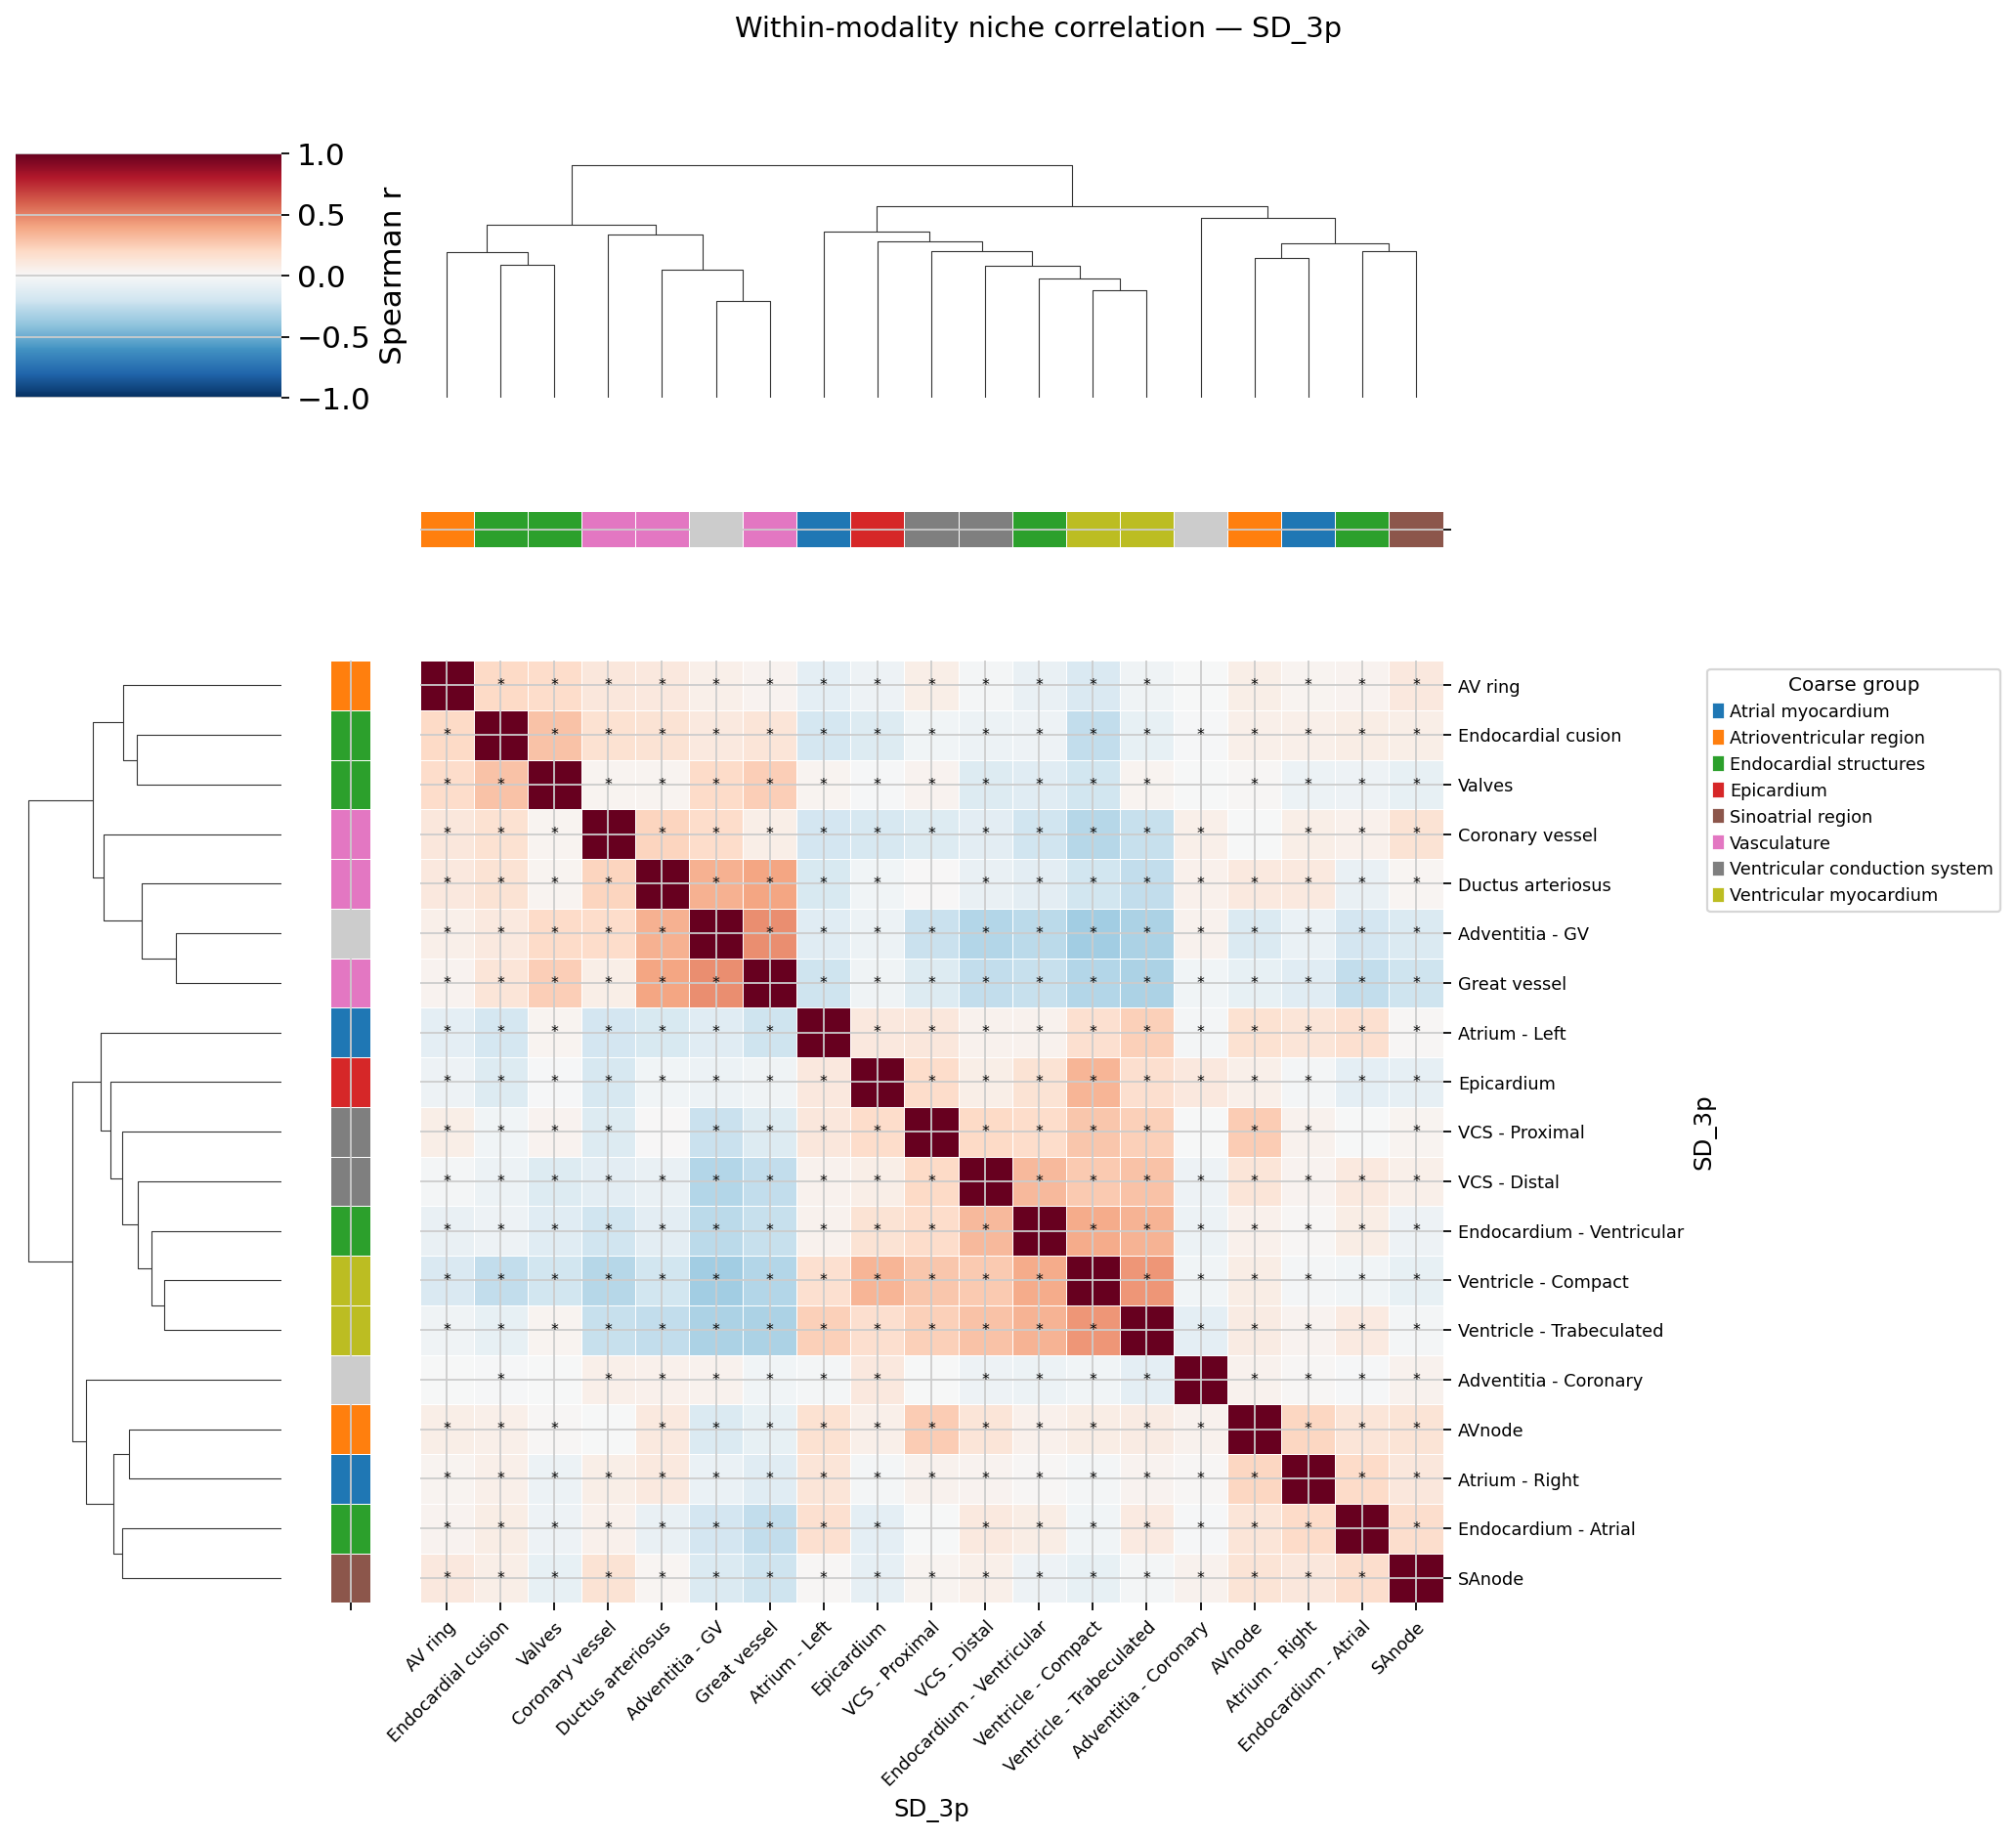


Computing: SD_FFPE ...
Saved: validation_plots/within_corr_SD_FFPE.png


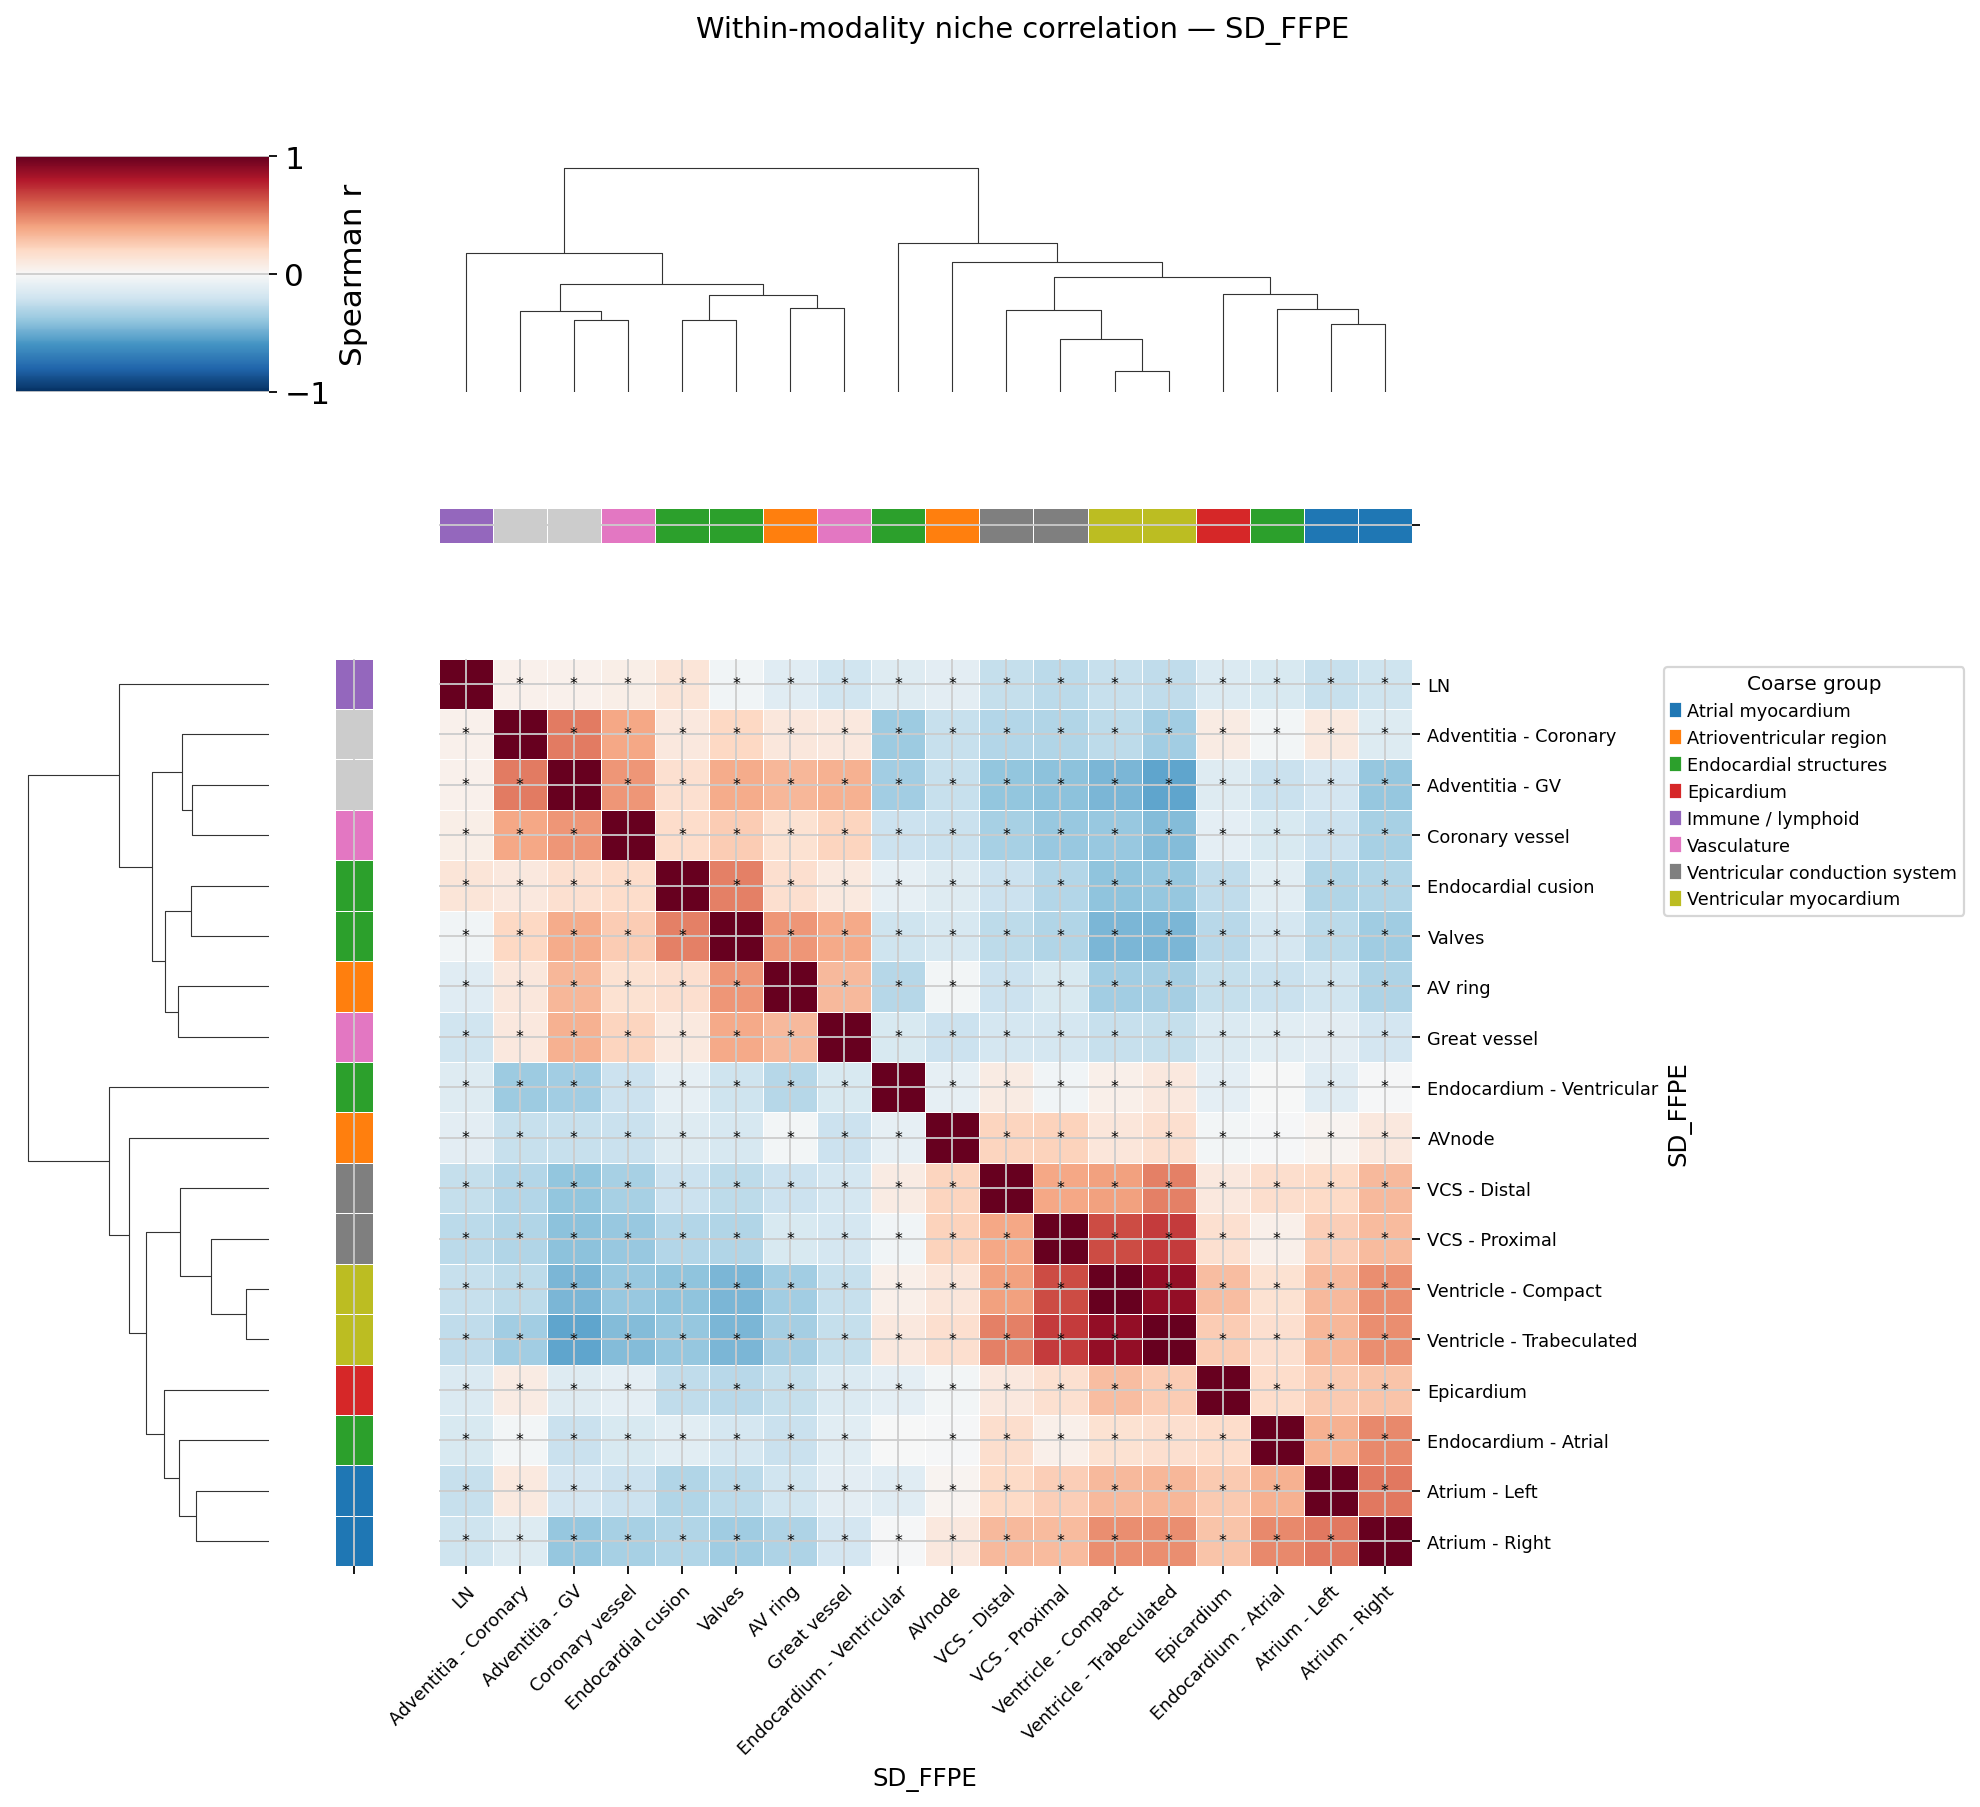


Computing: HD_FFPE ...
Saved: validation_plots/within_corr_HD_FFPE.png


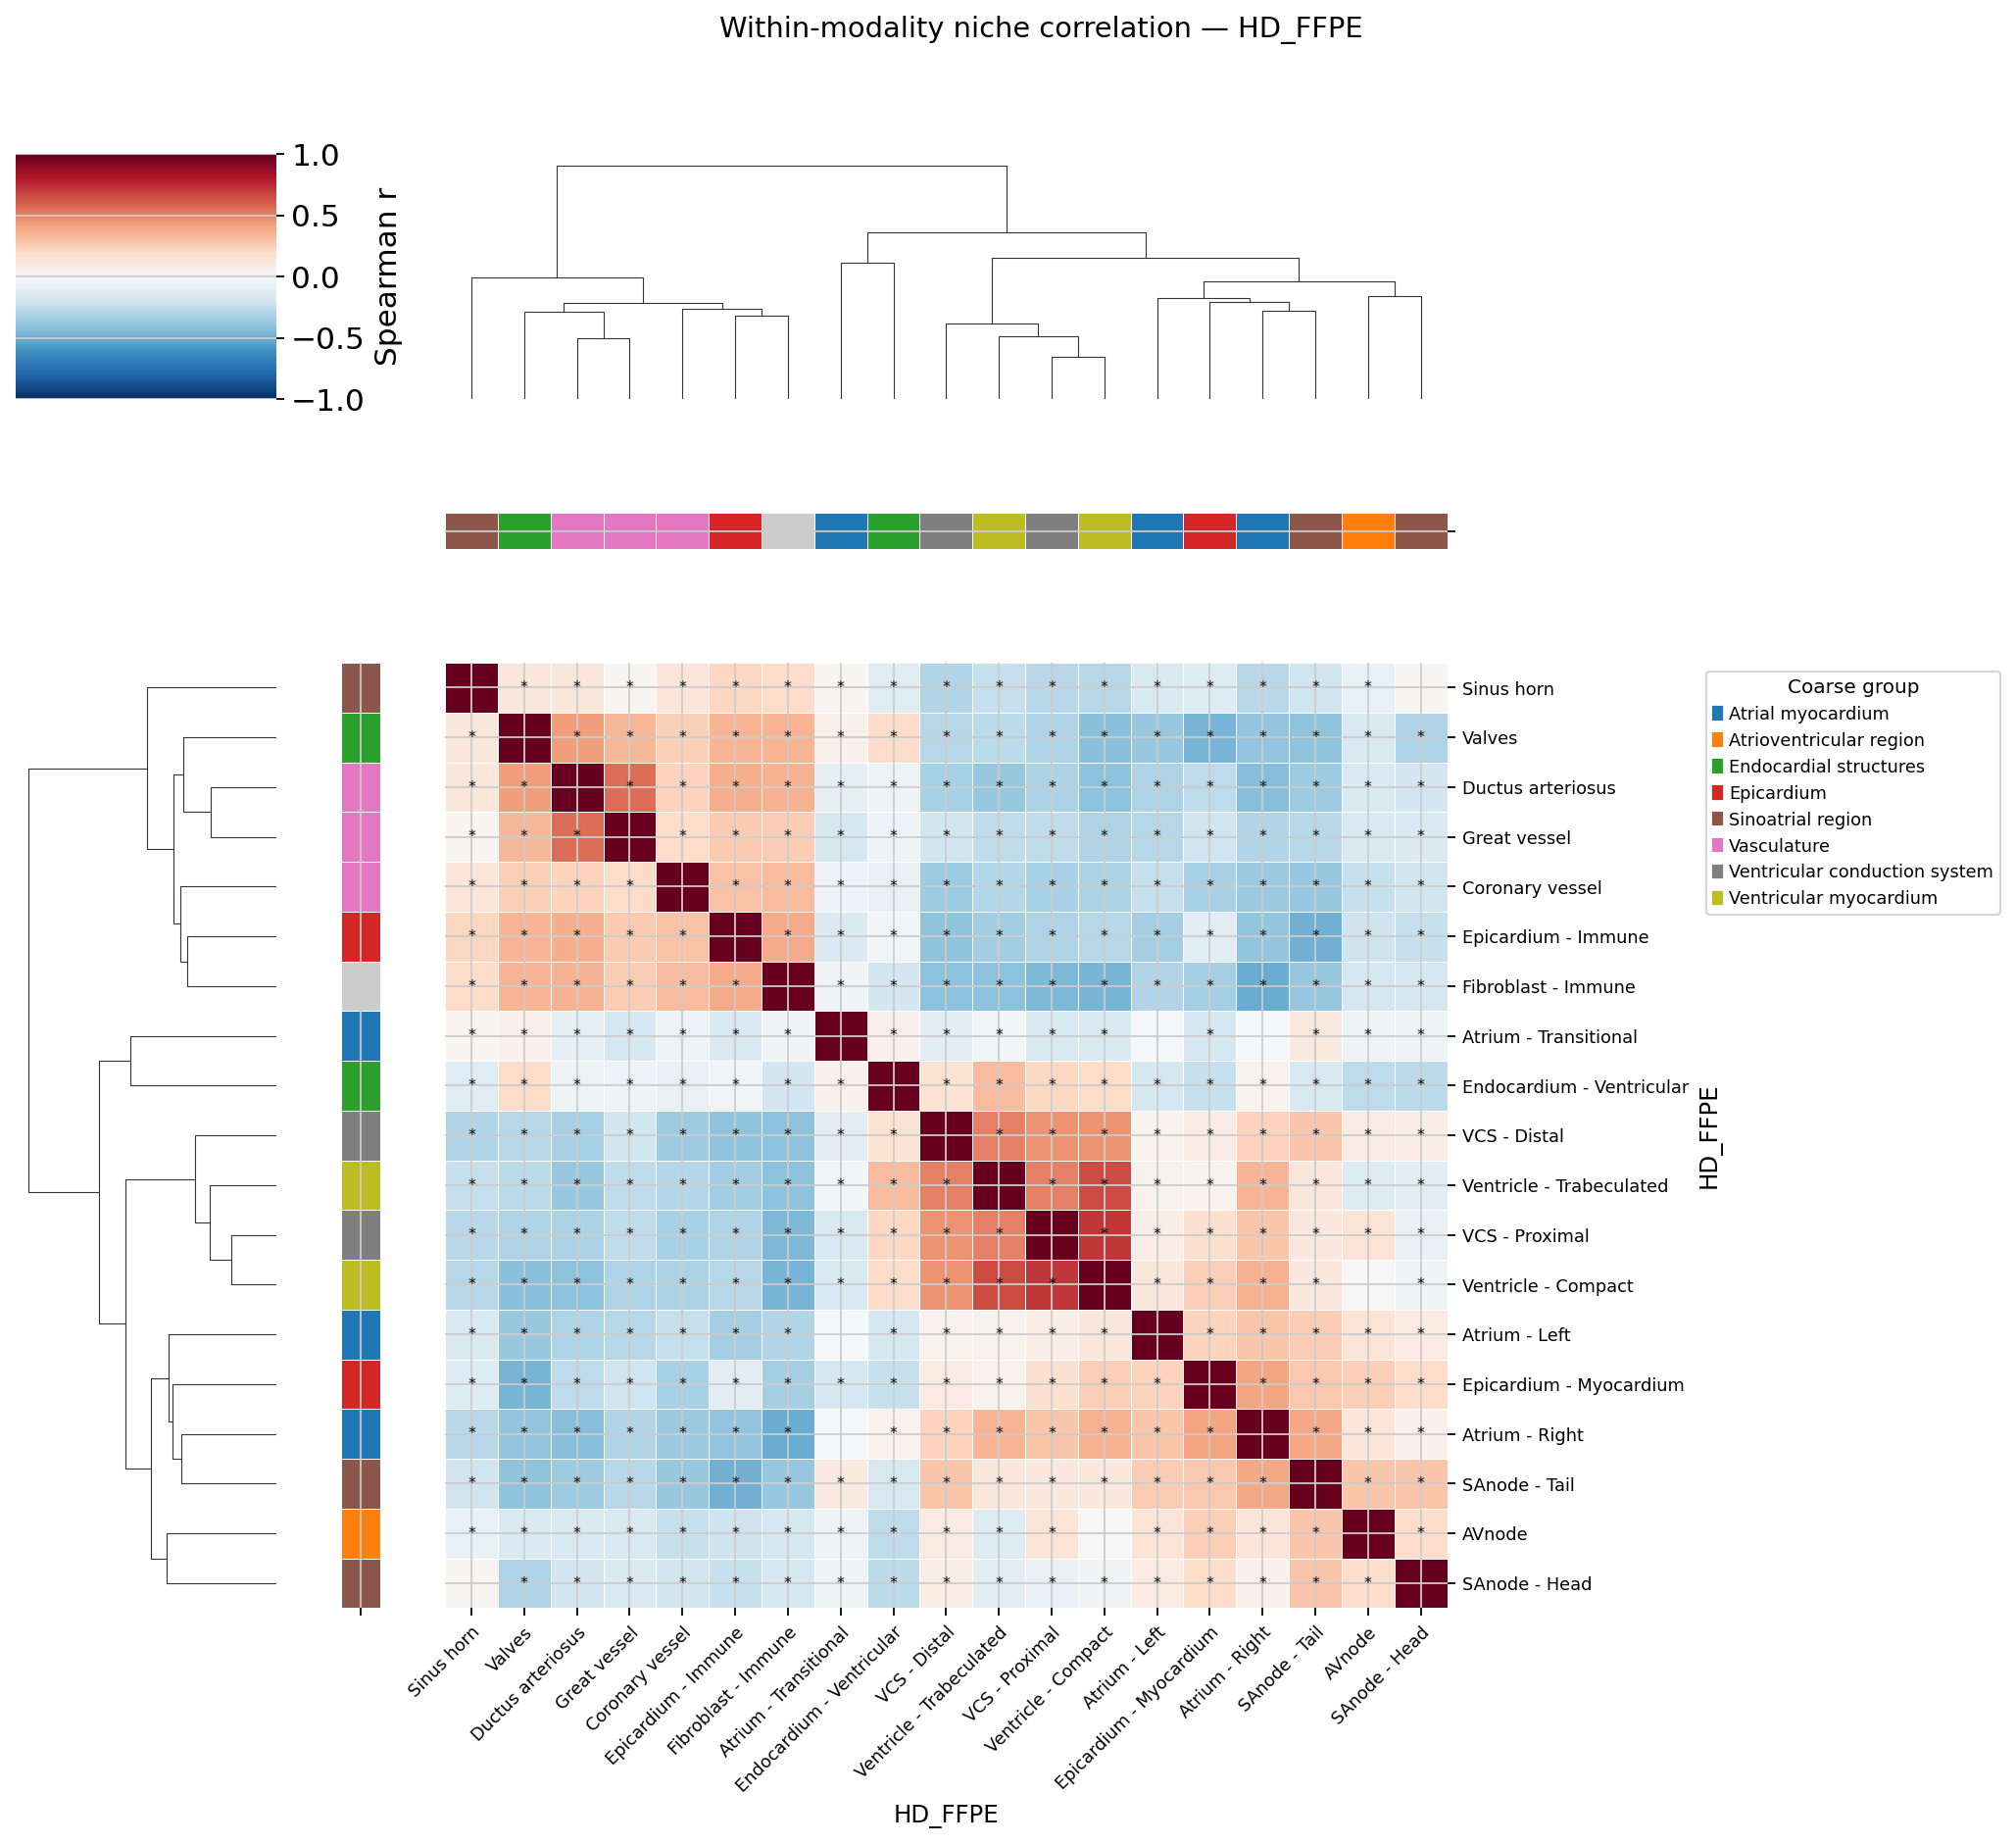

In [22]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


def niche_correlation_matrix(pb, 
                              niche_col="niche",
                              method="spearman"):
    """
    Compute symmetric niche x niche correlation matrix.

    Parameters
    ----------
    method : "pearson" or "spearman"
             For within-modality: pearson recommended (after z-score)
             For cross-modality:  spearman recommended (rank-robust)
    """
    from scipy.sparse import issparse
    from scipy.stats import spearmanr, pearsonr

    X = pb.X.copy().astype(float)
    if issparse(X):
        X = X.toarray()
    X = StandardScaler().fit_transform(X)

    niches_sorted = sorted(pb.obs[niche_col].unique())
    profiles = {
        niche: X[pb.obs[niche_col].values == niche].mean(axis=0)
        for niche in niches_sorted
    }

    r_matrix = pd.DataFrame(index=niches_sorted,
                             columns=niches_sorted, dtype=float)
    p_matrix = pd.DataFrame(index=niches_sorted,
                             columns=niches_sorted, dtype=float)

    for niche_a in niches_sorted:
        for niche_b in niches_sorted:
            if niche_a == niche_b:
                r_matrix.loc[niche_a, niche_b] = 1.0
                p_matrix.loc[niche_a, niche_b] = 0.0
            else:
                if method == "spearman":
                    r, p = spearmanr(profiles[niche_a],
                                     profiles[niche_b])
                elif method == "pearson":
                    r, p = pearsonr(profiles[niche_a],
                                    profiles[niche_b])
                else:
                    raise ValueError(
                        f"method must be 'pearson' or 'spearman', "
                        f"got '{method}'"
                    )
                r_matrix.loc[niche_a, niche_b] = round(r, 4)
                p_matrix.loc[niche_a, niche_b] = round(p, 4)

    return r_matrix, p_matrix


def plot_clustermap(r_matrix,
                    p_matrix=None,
                    modality_label="modality",
                    coarse_group_map=None,
                    annotate_pval=True,
                    pval_threshold=0.05,
                    figsize=None,
                    save_path=None):
    """
    Symmetric clustermap of niche x niche Spearman r.

    Parameters
    ----------
    r_matrix         : (niches x niches) DataFrame of Spearman r
    p_matrix         : optional (niches x niches) DataFrame of p-values
    modality_label   : string for title and axis labels
    coarse_group_map : optional dict {niche: coarse_group}
                       for color bar annotation
    """
    niches = list(r_matrix.index)

    # ── color bar ───────────────────────────────────────────────
    if coarse_group_map is not None:
        all_groups    = sorted(set(coarse_group_map.values()))
        group_palette = dict(zip(
            all_groups,
            sns.color_palette("tab10", len(all_groups))
        ))
        row_colors = pd.Series(
            [group_palette.get(
                 coarse_group_map.get(n, "unknown"),
                 (0.8, 0.8, 0.8))
             for n in niches],
            index=niches,
        )
    else:
        row_colors    = None
        group_palette = {}

    # ── figure size ─────────────────────────────────────────────
    n = len(niches)
    if figsize is None:
        figsize = (max(10, n * 0.5 + 4),
                   max(8,  n * 0.45 + 3))

    # ── clustermap ──────────────────────────────────────────────
    g = sns.clustermap(
        r_matrix.astype(float),
        row_cluster  = True,
        col_cluster  = True,
        row_colors   = row_colors,
        col_colors   = row_colors,
        cmap         = "RdBu_r",
        center       = 0,
        vmin         = -1,
        vmax         = 1,
        linewidths   = 0.3,
        linecolor    = "white",
        figsize      = figsize,
        cbar_kws     = {"label": "Spearman r"},
        xticklabels  = True,
        yticklabels  = True,
    )

    # ── p-value stars ────────────────────────────────────────────
    if annotate_pval and p_matrix is not None:
        row_ord = g.dendrogram_row.reordered_ind
        col_ord = g.dendrogram_col.reordered_ind
        reordered_rows = r_matrix.index[row_ord]
        reordered_cols = r_matrix.columns[col_ord]

        for i, na in enumerate(reordered_rows):
            for j, nb in enumerate(reordered_cols):
                if na == nb:
                    continue
                if p_matrix.loc[na, nb] < pval_threshold:
                    g.ax_heatmap.text(
                        j + 0.5, i + 0.5, "*",
                        ha="center", va="center",
                        fontsize=7, color="black",
                    )

    # ── labels ───────────────────────────────────────────────────
    g.ax_heatmap.set_xlabel(modality_label, fontsize=11)
    g.ax_heatmap.set_ylabel(modality_label, fontsize=11)
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=45, ha="right",
        rotation_mode="anchor", fontsize=8,
    )
    g.ax_heatmap.tick_params(axis="y", labelsize=8, rotation=0)

    # ── legend ───────────────────────────────────────────────────
    if group_palette:
        present = {coarse_group_map.get(n) for n in niches
                   if coarse_group_map.get(n)}
        handles = [
            mpatches.Patch(color=col, label=grp)
            for grp, col in group_palette.items()
            if grp in present
        ]
        g.ax_heatmap.legend(
            handles=handles, title="Coarse group",
            bbox_to_anchor=(1.25, 1), loc="upper left",
            fontsize=8, title_fontsize=9,
        )

    plt.suptitle(
        f"Within-modality niche correlation — {modality_label}",
        y=1.02, fontsize=13,
    )
    plt.tight_layout()

    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    return g


# ================================================================
# RUN
# ================================================================

# optional — define once, pass to all plots
coarse_group_map = {
    "Sinus horn":               "Sinoatrial region",
    "SAnode":                   "Sinoatrial region",
    "SAnode - Head":            "Sinoatrial region",
    "SAnode - Tail":            "Sinoatrial region",
    "AV ring":                  "Atrioventricular region",
    "AVnode":                   "Atrioventricular region",
    "VCS - Proximal":           "Ventricular conduction system",
    "VCS - Distal":             "Ventricular conduction system",
    "Atrium":                   "Atrial myocardium",
    "Atrium - Left":            "Atrial myocardium",
    "Atrium - Right":           "Atrial myocardium",
    "Atrium - Transitional":    "Atrial myocardium",
    "Ventricle - Compact":      "Ventricular myocardium",
    "Ventricle - Trabeculated": "Ventricular myocardium",
    "Endocardium":              "Endocardial structures",
    "Endocardium - Atrial":     "Endocardial structures",
    "Endocardium - Ventricular":"Endocardial structures",
    "Endocardial cusion":       "Endocardial structures",
    "Valves":                   "Endocardial structures",
    "Epicardium":               "Epicardium",
    "Epicardium - Immune":      "Epicardium",
    "Epicardium - Myocardium":  "Epicardium",
    "Great vessel":             "Vasculature",
    "Adventitia":               "Vasculature",
    "Coronary vessel":          "Vasculature",
    "Ductus arteriosus":        "Vasculature",
    "Cardiac mesenchyme":       "Vasculature",   # updated placement
    "LN":                       "Immune / lymphoid",
}

modality_pbs = [
    (pb_sd3p,  "SD_3p"),
    (pb_sdffe, "SD_FFPE"),
    (pb_hd,    "HD_FFPE"),
]

all_within_r = {}

for pb, label in modality_pbs:
    print(f"\nComputing: {label} ...")

    r_matrix, p_matrix = niche_correlation_matrix(pb, niche_col="niche")
    all_within_r[label] = r_matrix

    plot_clustermap(
        r_matrix         = r_matrix,
        p_matrix         = p_matrix,
        modality_label   = label,
        coarse_group_map = coarse_group_map,   # pass directly
        annotate_pval    = True,
        pval_threshold   = 0.05,
        save_path        = f"validation_plots/within_corr_{label}.png",
    )

<u>**Observations and Decisions**</u>
- (obs) The adventitia niches seem to have a high correlation (Coronary or GV). Especially in the FFPE dataset.
- (obs) In the previous version of TissueTypist, "Adventitia - Coronary" showed low accuracy.
- (dec) We will merge the two niches ("Adventitia - Coronary" and "Adventitia - GV") as one label: "Adventitia"

# Reconsidering "Fibroblast - Immune" niche

- It shows high correation with vessels. Could this be adventitia?

In [23]:
# compute markers per niche
def compute_markers(pb, niche_col="niche",
                    modality_col="modality",
                    top_n=300):
    """
    Fully vectorised 1-vs-rest markers with within-modality z-scoring.

    Parameters
    ----------
    pb           : AnnData pseudobulk object
    niche_col    : obs column with niche labels
    modality_col : obs column with modality labels
                   (used for within-modality z-scoring)
                   pass None to use global z-score instead
    top_n        : number of top markers to return per niche
    """
    from scipy.sparse import issparse

    X = pb.X.copy().astype(np.float32)
    if issparse(X):
        X = X.toarray()

    # --- z-score: within-modality (recommended) or global ---
    if modality_col is not None and modality_col in pb.obs.columns:
        modalities = pb.obs[modality_col].values
        for mod in np.unique(modalities):
            mask = modalities == mod
            mean = X[mask].mean(axis=0, keepdims=True)
            std  = X[mask].std(axis=0, keepdims=True)
            std[std == 0] = 1
            X[mask] = (X[mask] - mean) / std
    else:
        # fallback: global z-score
        mean = X.mean(axis=0, keepdims=True)
        std  = X.std(axis=0, keepdims=True)
        std[std == 0] = 1
        X = (X - mean) / std

    niches      = pb.obs[niche_col].values
    genes       = np.array(pb.var_names)
    uniq_niches = np.unique(niches)
    n_total     = X.shape[0]

    # --- pre-compute ranks once for all niches ---
    order = X.argsort(axis=0)
    ranks = np.empty_like(order, dtype=np.float32)
    ranks[order, np.arange(X.shape[1])] = \
        np.arange(n_total, dtype=np.float32)[:, None]
    ranks += 1   # 1-based

    results = {}

    for niche in uniq_niches:
        mask  = niches == niche
        n_pos = mask.sum()
        n_neg = n_total - n_pos

        if n_pos < 2:
            continue

        # AUROC via Mann-Whitney U
        rank_sum = ranks[mask].sum(axis=0)
        U        = rank_sum - n_pos * (n_pos + 1) / 2
        aurocs   = (U / (n_pos * n_neg)).astype(np.float32)

        # logFC in within-modality z-score units
        logfcs = (X[mask].mean(axis=0) -
                  X[~mask].mean(axis=0)).astype(np.float32)

        # top_n via partial sort (O(n) vs O(n log n))
        if top_n < len(genes):
            top_idx = np.argpartition(aurocs, -top_n)[-top_n:]
            top_idx = top_idx[np.argsort(aurocs[top_idx])[::-1]]
        else:
            top_idx = np.argsort(aurocs)[::-1]

        results[niche] = pd.DataFrame({
            "gene":    genes[top_idx],
            "auroc":   aurocs[top_idx],
            "logfc_z": logfcs[top_idx],
        }).reset_index(drop=True)

    return results

def compute_markers_single_cell(adata, niche_col="niche", top_n=300):
    """
    Same vectorised AUROC logic but operates on 
    single cells instead of pseudobulks.
    Use only when pseudobulking isn't possible 
    (e.g. single donor, single section).
    """
    from scipy.sparse import issparse

    X = adata.X.copy().astype(np.float32)
    if issparse(X):
        X = X.toarray()

    # z-score globally (no modality correction needed 
    # within a single dataset)
    mean = X.mean(axis=0, keepdims=True)
    std  = X.std(axis=0, keepdims=True)
    std[std == 0] = 1
    X = (X - mean) / std

    niches      = adata.obs[niche_col].values
    genes       = np.array(adata.var_names)
    uniq_niches = np.unique(niches)
    n_total     = X.shape[0]

    # pre-compute ranks once
    order = X.argsort(axis=0)
    ranks = np.empty_like(order, dtype=np.float32)
    ranks[order, np.arange(X.shape[1])] = \
        np.arange(n_total, dtype=np.float32)[:, None]
    ranks += 1

    results = {}
    for niche in uniq_niches:
        mask  = niches == niche
        n_pos = mask.sum()
        n_neg = n_total - n_pos

        if n_pos < 2:
            continue

        rank_sum = ranks[mask].sum(axis=0)
        U        = rank_sum - n_pos * (n_pos + 1) / 2
        aurocs   = (U / (n_pos * n_neg)).astype(np.float32)
        logfcs   = (X[mask].mean(axis=0) - 
                    X[~mask].mean(axis=0)).astype(np.float32)

        if top_n < len(genes):
            top_idx = np.argpartition(aurocs, -top_n)[-top_n:]
            top_idx = top_idx[np.argsort(aurocs[top_idx])[::-1]]
        else:
            top_idx = np.argsort(aurocs)[::-1]

        results[niche] = pd.DataFrame({
            "gene":    genes[top_idx],
            "auroc":   aurocs[top_idx],
            "logfc_z": logfcs[top_idx],
        }).reset_index(drop=True)

    return results

### Running ###
markers_sd3p  = compute_markers(pb_sd3p,niche_col='niche',modality_col = None)
markers_hd    = compute_markers(pb_hd,niche_col='niche',modality_col = None)

# log-normalise SD_FFPE data
ad = adata_sd_ffpe.copy() # the "Adventitia" annotation is already updated

print(ad.X.data[:5])
sc.pp.filter_genes(ad, min_cells=3)
sc.pp.normalize_total(ad,target_sum=1e4)
sc.pp.log1p(ad)
print(ad.X.data[:5])

markers_sdffe = compute_markers_single_cell(ad,niche_col='annotation_final_mod')

[308.  36.  58. 486. 168.]
[0.45308918 0.25198928 0.6204403  0.45308918 0.45308918]


In [24]:
# Checking what gene markers are there for the "Fibroblast - Immune" and "Adventitia" niche
epdc_markers    = ["WT1", "TBX18", "ALDH1A2", "TCF21", "PDGFRA"]
fibro_markers   = ["COL1A1", "COL3A1", "POSTN", "DCN", "LUM"]
immune_markers  = ["CD14","CD163", "CD68", "CD3D", "CD19", "LYVE1"]
smooth_muscle   = ["ACTA2", "MYH11", "TAGLN"]
lec_markers     = ['LYVE1','CCL21','PDPN','PROX1']

for label, markers in [
    ("EPDC",         epdc_markers),
    ("Fibroblast",   fibro_markers),
    ("Immune",       immune_markers),
    ("Smooth muscle",smooth_muscle),
    ("LEC",          lec_markers)
]:
    for mod, markers_dict, niche in [
        ("HD_FFPE", markers_hd,    "Fibroblast - Immune"),
        ("SD_FFPE", markers_sdffe, "Adventitia - Coronary"),
        ("SD_FFPE", markers_sdffe, "Adventitia - GV"),
    ]:
        if niche not in markers_dict:
            continue
        top_genes = set(markers_dict[niche]["gene"].head(100))
        overlap   = top_genes & set(markers)
        print(f"  [{mod}] {niche} vs {label}: "
              f"{len(overlap)}/{len(markers)} → {overlap}")

  [HD_FFPE] Fibroblast - Immune vs EPDC: 0/5 → set()
  [SD_FFPE] Adventitia - Coronary vs EPDC: 2/5 → {'TCF21', 'TBX18'}
  [SD_FFPE] Adventitia - GV vs EPDC: 1/5 → {'PDGFRA'}
  [HD_FFPE] Fibroblast - Immune vs Fibroblast: 0/5 → set()
  [SD_FFPE] Adventitia - Coronary vs Fibroblast: 5/5 → {'COL3A1', 'COL1A1', 'POSTN', 'DCN', 'LUM'}
  [SD_FFPE] Adventitia - GV vs Fibroblast: 5/5 → {'COL3A1', 'COL1A1', 'POSTN', 'DCN', 'LUM'}
  [HD_FFPE] Fibroblast - Immune vs Immune: 0/6 → set()
  [SD_FFPE] Adventitia - Coronary vs Immune: 1/6 → {'LYVE1'}
  [SD_FFPE] Adventitia - GV vs Immune: 1/6 → {'LYVE1'}
  [HD_FFPE] Fibroblast - Immune vs Smooth muscle: 0/3 → set()
  [SD_FFPE] Adventitia - Coronary vs Smooth muscle: 0/3 → set()
  [SD_FFPE] Adventitia - GV vs Smooth muscle: 0/3 → set()
  [HD_FFPE] Fibroblast - Immune vs LEC: 0/4 → set()
  [SD_FFPE] Adventitia - Coronary vs LEC: 1/4 → {'LYVE1'}
  [SD_FFPE] Adventitia - GV vs LEC: 1/4 → {'LYVE1'}


In [26]:
# just making some notes
notable_genes = {
    # Mesenchymal/connective tissue identity
    "DDR2":   "collagen receptor — mesenchymal marker",
    "GPC6":   "glypican-6 — mesenchymal ECM signalling, expressed in cardiac cushions",
    "ITGB8":  "integrin beta-8 — TGFb activation, mesenchymal",
    "BNC2":   "basonuclin-2 — mesenchymal TF",
    
    # Developmental signalling
    "SEMA3C": "semaphorin — outflow tract, neural crest guidance",
    "RSPO2":  "R-spondin 2 — WNT potentiator, limb/cardiac mesenchyme",
    "GLI2":   "hedgehog effector — cardiac progenitor niche",
    "ADAMTS5":"ECM remodelling — valve/cushion development",
    
    # TF signature
    "ZFPM2":  "FOG2 — epicardial/myocardial TF, NOT fibroblast",
    "MEOX2":  "vascular/mesenchymal progenitor",
    "NFIA":   "broad progenitor TF",
    "HLX":    "mesenchymal homeobox TF",
    "KLF12":  "mesenchymal TF",
    "EYA2":   "cardiac progenitor — SHF marker",  # worth noting
    
    # Notably absent
    # COL1A1, COL3A1, POSTN, DCN, VIM → not a mature fibroblast
    # PTPRC, CD68, CD3D → not immune
    # ACTA2, MYH11 → not smooth muscle
}

<u>**Observations and Decisions**</u>
- (obs) "Adventitia" niches includes clear fibroblast markers
- (obs) "Fibroblast - Immune" niche has focal, peripheral, close-to-vessels spatial pattern (no07 notebook in the 6_cellular_niche_prediction directory)
- (obs) "Fibroblast - Immune" is potentially progenitor niche rather than structural fibroblast
- (dec) "Adventitia" --> keep as it is
- (dec) "Fibroblast - Immune" --> rename as "Cardiac mesenchyme" 

# Whether we want to merge "Valves" and "Endocardial cushion"

- Endocardial cusion: Transient embryonic structure — endocardial cells undergo EMT to form mesenchymal cushion tissue.
- Valves: Mature valve structure — valve interstitial cells (VICs) + valve endothelial cells (VECs). Arises from remodelled cushion.
- Our Visium datasets spans 4-20PCW and the query dataset will be similarly broad. So this range has both active early cusion and remodelling/valve stages. The boundary between them is blurry in a development dataset.
- **<u>If the gene signatures are similar<\u>**, we will merge rather than separate which may lead to misinterpretation.

In [27]:
modality_pbs = [
    (pb_sd3p,  "SD_3p"),
    (pb_sdffe, "SD_FFPE"),
    (pb_hd,    "HD_FFPE"),
]

all_within_r = {}
for pb, label in modality_pbs:
    print(f"Computing: {label} ...")
    r_matrix, p_matrix = niche_correlation_matrix(pb, niche_col="niche", method="spearman")
    all_within_r[label] = r_matrix

print('')
    
# ── Step 1: correlation across modalities ───────────────────────
print("=== Correlation: Valves × Endocardial cushion ===\n")
for label, r_mat in all_within_r.items():
    if "Valves" in r_mat.index and "Endocardial cusion" in r_mat.index:
        r = r_mat.loc["Valves", "Endocardial cusion"]
        print(f"[{label}] r = {r:.3f}")
    else:
        print(f"[{label}] one or both niches absent")

# ── Step 2: marker overlap ───────────────────────────────────────
print("\n=== Marker overlap: Valves × Endocardial cushion ===\n")
for modality, markers in {"SD_3p":   markers_sd3p,
                           "SD_FFPE": markers_sdffe,
                           "HD_FFPE": markers_hd}.items():
    if "Valves" not in markers or "Endocardial cusion" not in markers:
        print(f"[{modality}] one or both absent")
        continue

    genes_v = set(markers["Valves"]["gene"].head(300))
    genes_c = set(markers["Endocardial cusion"]["gene"].head(300))
    shared  = genes_v & genes_c
    jaccard = len(shared) / len(genes_v | genes_c)

    print(f"[{modality}]")
    print(f"  Jaccard:        {jaccard:.3f}")
    print(f"  Shared ({len(shared)}): {sorted(shared)}")

    # check for EMT markers that would argue for keeping separate
    emt_markers   = ["TWIST1", "SNAI2", "MSX1", "MSX2",
                     "ACTA2", "VIM", "CDH2"]
    valve_markers = ["NFATC1", "SOX9", "HAPLN1", 
                     "SCX", "TNNI1", "POSTN"]

    print(f"  EMT markers in Cushion top 300: "
          f"{set(markers['Endocardial cusion']['gene'].head(300)) & set(emt_markers)}")
    print(f"  EMT markers in Valves top 300:  "
          f"{genes_v & set(emt_markers)}")
    print(f"  Valve markers in Cushion top 300: "
          f"{set(markers['Endocardial cusion']['gene'].head(300)) & set(valve_markers)}")
    print(f"  Valve markers in Valves top 300:  "
          f"{genes_v & set(valve_markers)}")

Computing: SD_3p ...
Computing: SD_FFPE ...
Computing: HD_FFPE ...

=== Correlation: Valves × Endocardial cushion ===

[SD_3p] r = 0.292
[SD_FFPE] r = 0.503
[HD_FFPE] one or both niches absent

=== Marker overlap: Valves × Endocardial cushion ===

[SD_3p]
  Jaccard:        0.020
  Shared (12): ['EDIL3', 'ENPP3', 'EPB41L4B', 'FUT8', 'HAPLN1', 'LRP11', 'MSX1', 'NRCAM', 'PPT1', 'RHOU', 'SFT2D2', 'SLC22A3']
  EMT markers in Cushion top 300: {'VIM', 'MSX1'}
  EMT markers in Valves top 300:  {'MSX1'}
  Valve markers in Cushion top 300: {'HAPLN1', 'NFATC1'}
  Valve markers in Valves top 300:  {'HAPLN1', 'SOX9'}
[SD_FFPE]
  Jaccard:        0.471
  Shared (192): ['ABI3BP', 'ACTB', 'ACTG1', 'ACTN1', 'ADAMTS19', 'ADGRA2', 'AEBP1', 'AHR', 'AMOTL1', 'ANGPTL2', 'ANXA1', 'ANXA2', 'APCDD1', 'ARHGEF40', 'ASPN', 'B4GALT1', 'BASP1', 'BGN', 'BMP4', 'BMP6', 'BOC', 'C1QTNF1', 'C1QTNF6', 'C1R', 'CCDC80', 'CD200', 'CD276', 'CD9', 'CDH11', 'CDK2AP1', 'CGNL1', 'CHSY1', 'CLU', 'CMTM3', 'CMTM6', 'CNN3', 'COL12A1'

<u>**Observations and Decisions**</u>
- (obs) FFPE shows high correlation and Jaccard score --> it will be potentially difficult to distinguish
- (obs) 3prime shows moderate correlation and low Jaccard score --> it could be possible to distinguish
- (fact) in HD data, we only have "Valve" annotation which looks like endocardial cusion if you see the histology
- (dec) merge the two annotation as "Endocardial cushion / Valve"

# Update annotations

In [28]:
# Adventitia
adata_sd.obs.replace({niche_col:{
    "Adventitia - Coronary":"Adventitia",
    "Adventitia - GV"      :"Adventitia"
}}, inplace=True)

# Fibroblast - Immune
adata_hd.obs.replace({niche_col:{
    "Fibroblast - Immune"  :"Cardiac mesenchyme"
}}, inplace=True)

# Valves, Endocardial cushion
adata_sd.obs.replace({niche_col:{
    "Endocardial cusion" :"Endocardial cushion - Valve",
    "Valves"             :"Endocardial cushion - Valve"
}}, inplace=True)
adata_hd.obs.replace({niche_col:{
    "Valves"             :"Endocardial cushion - Valve"
}}, inplace=True)

# split SD data into 3p and FFPE
adata_sd_3p = adata_sd[adata_sd.obs['modality']=='Visium'].copy()
adata_sd_ffpe = adata_sd[adata_sd.obs['modality']=='Visium-FFPE'].copy()

In [29]:
set(pb_sd3p.obs['niche'])

{'AV ring',
 'AVnode',
 'Adventitia - Coronary',
 'Adventitia - GV',
 'Atrium - Left',
 'Atrium - Right',
 'Coronary vessel',
 'Ductus arteriosus',
 'Endocardial cusion',
 'Endocardium - Atrial',
 'Endocardium - Ventricular',
 'Epicardium',
 'Great vessel',
 'SAnode',
 'VCS - Distal',
 'VCS - Proximal',
 'Valves',
 'Ventricle - Compact',
 'Ventricle - Trabeculated'}

In [30]:
# make pseudobulks
pb_sd3p  = make_pseudobulks(adata_sd_3p, niche_col, "donor", "SD_3p")
pb_sdffe = make_pseudobulks(adata_sd_ffpe, niche_col, "donor", "SD_FFPE")
pb_hd    = make_pseudobulks(adata_hd, niche_col, "donor", "HD_FFPE")
print(pb_sd3p.shape)
print(pb_sdffe.shape)
print(pb_hd.shape)

(51, 33562)
(16, 33562)
(53, 18085)


Saved: validation_plots/within_corr_SD_3p_pearson.png


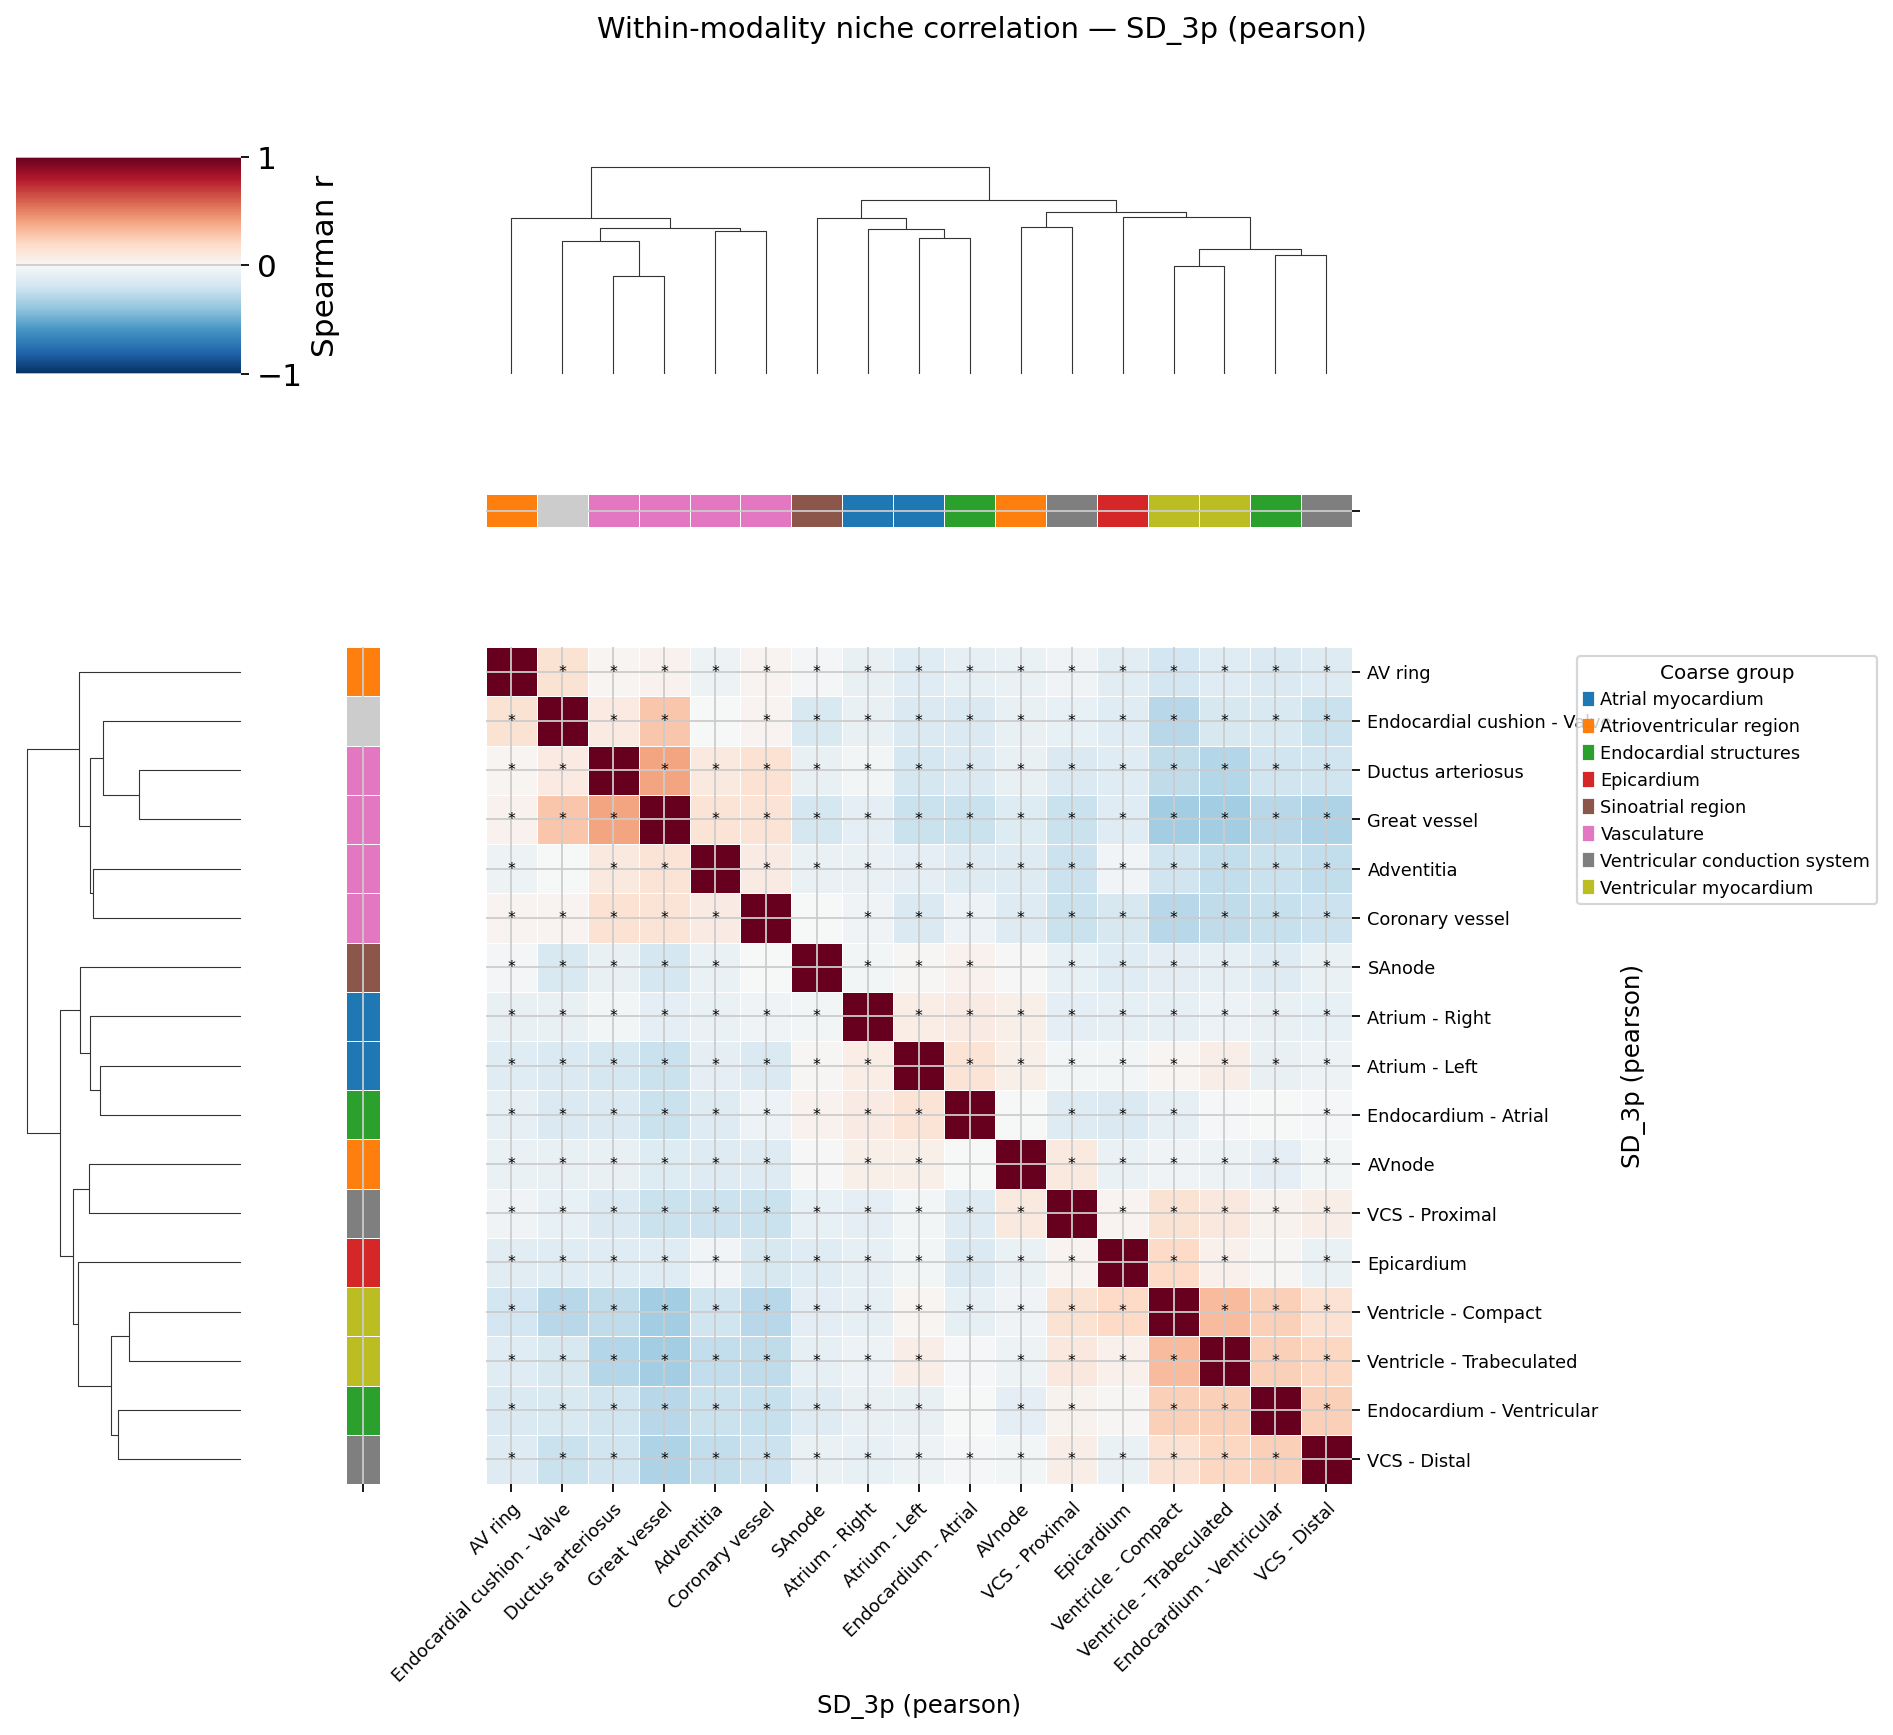

Saved: validation_plots/within_corr_SD_3p_spearman.png


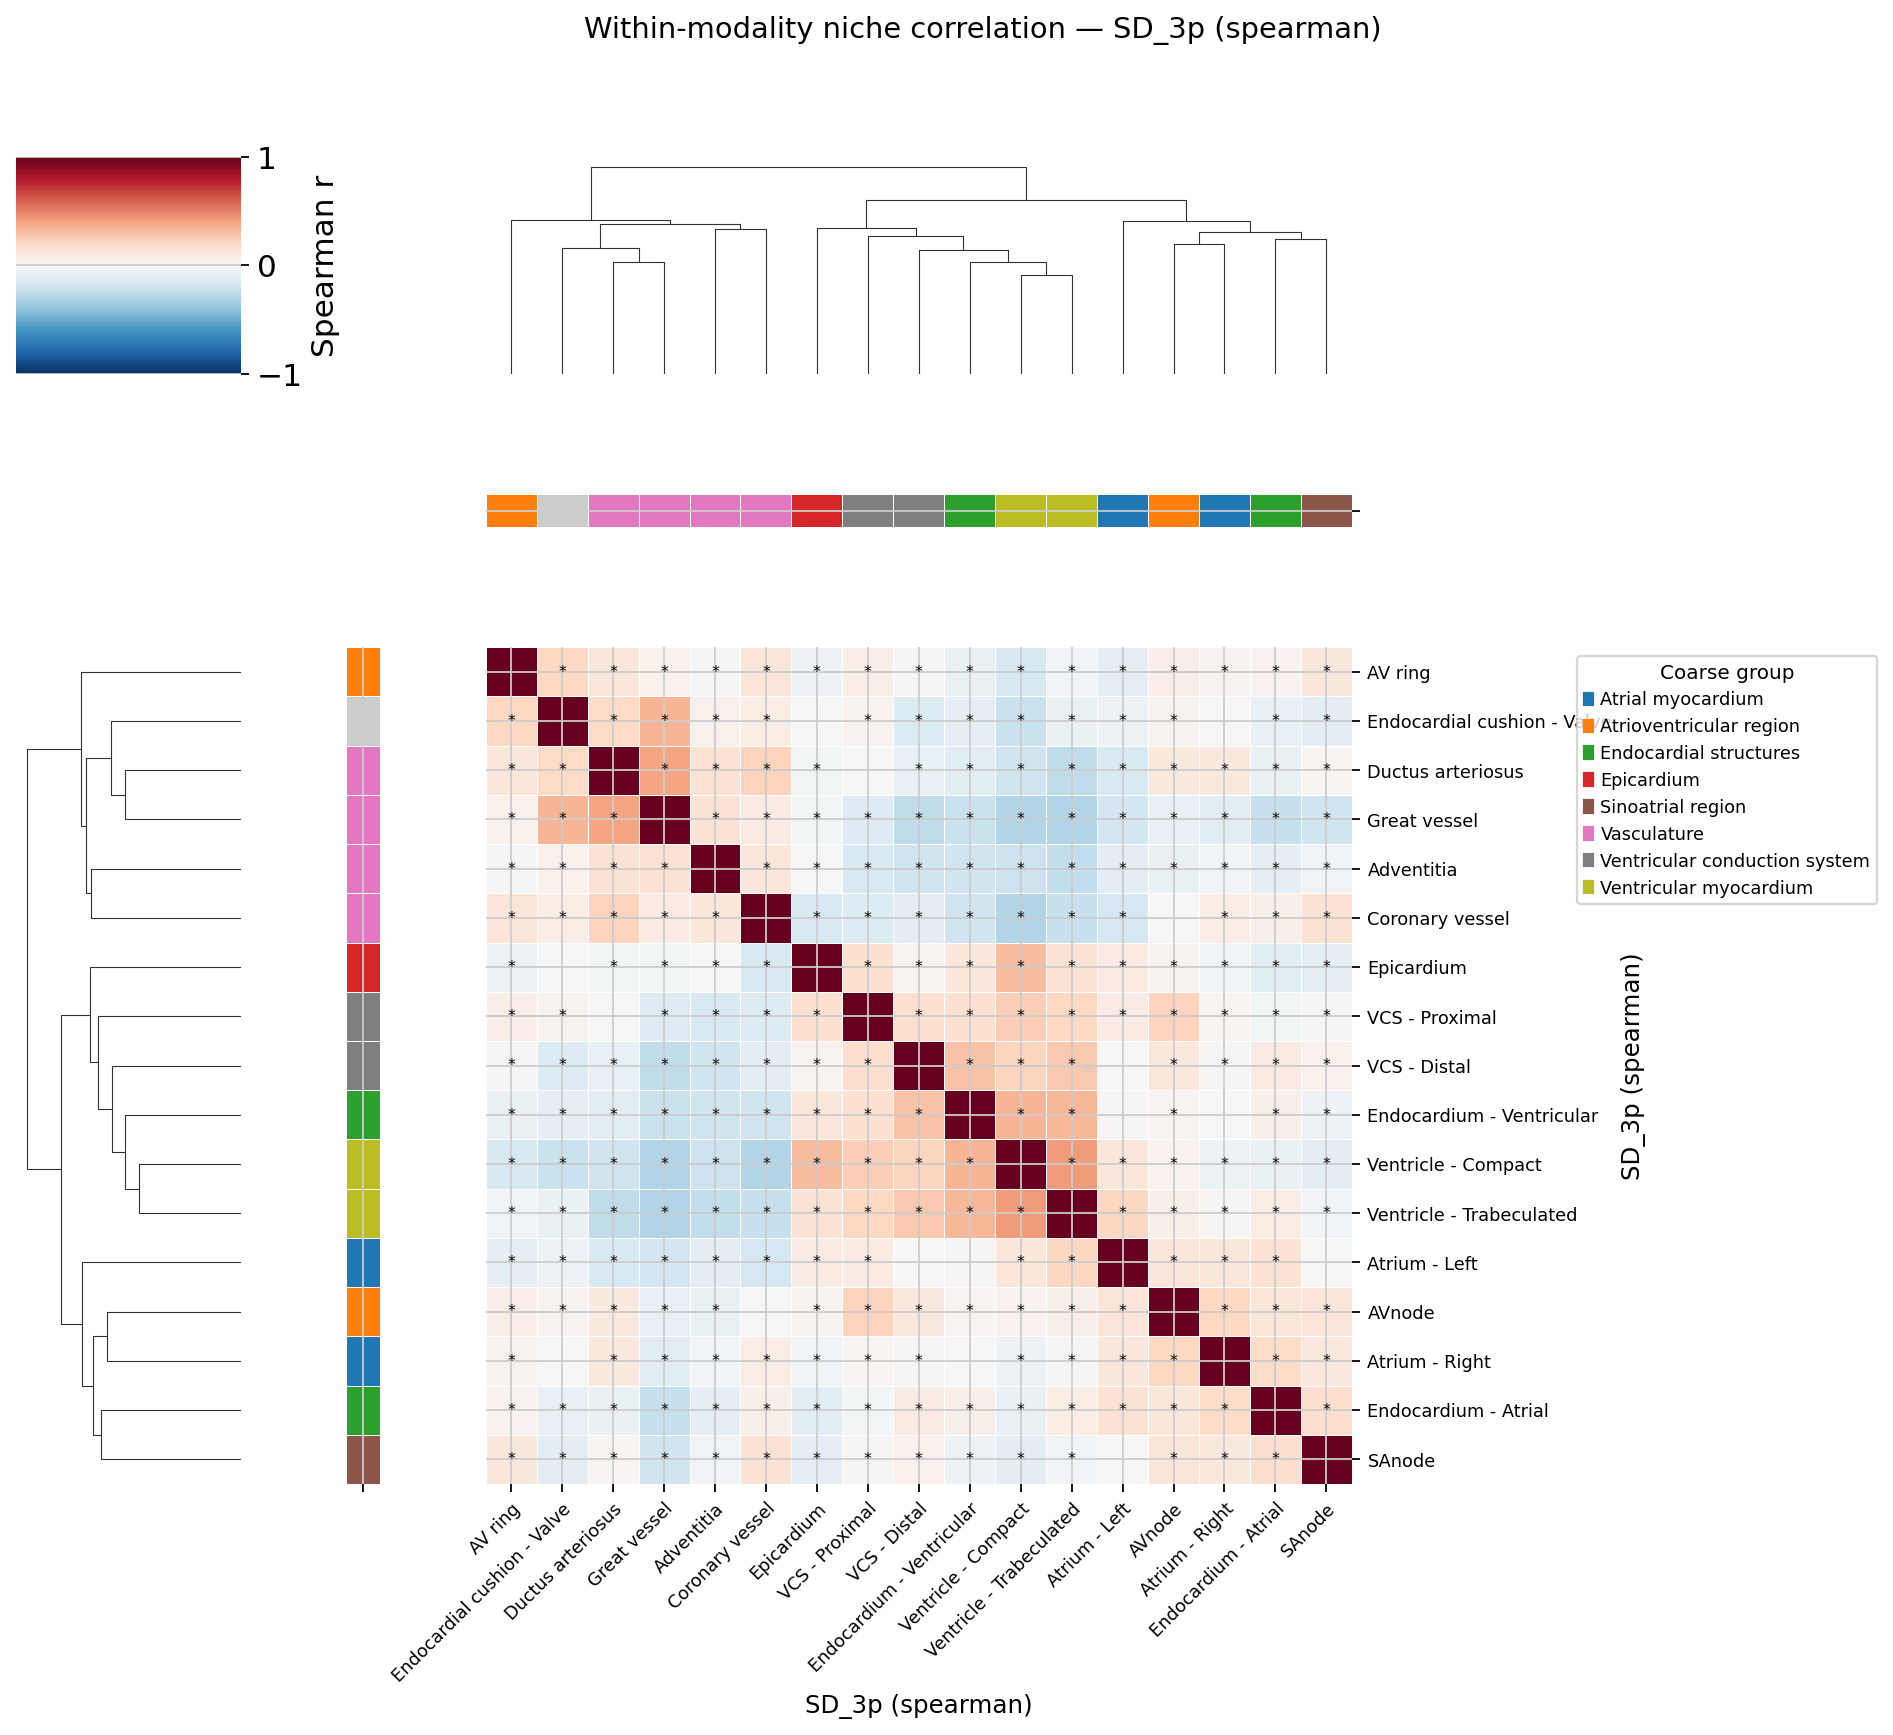

Saved: validation_plots/within_corr_SD_FFPE_pearson.png


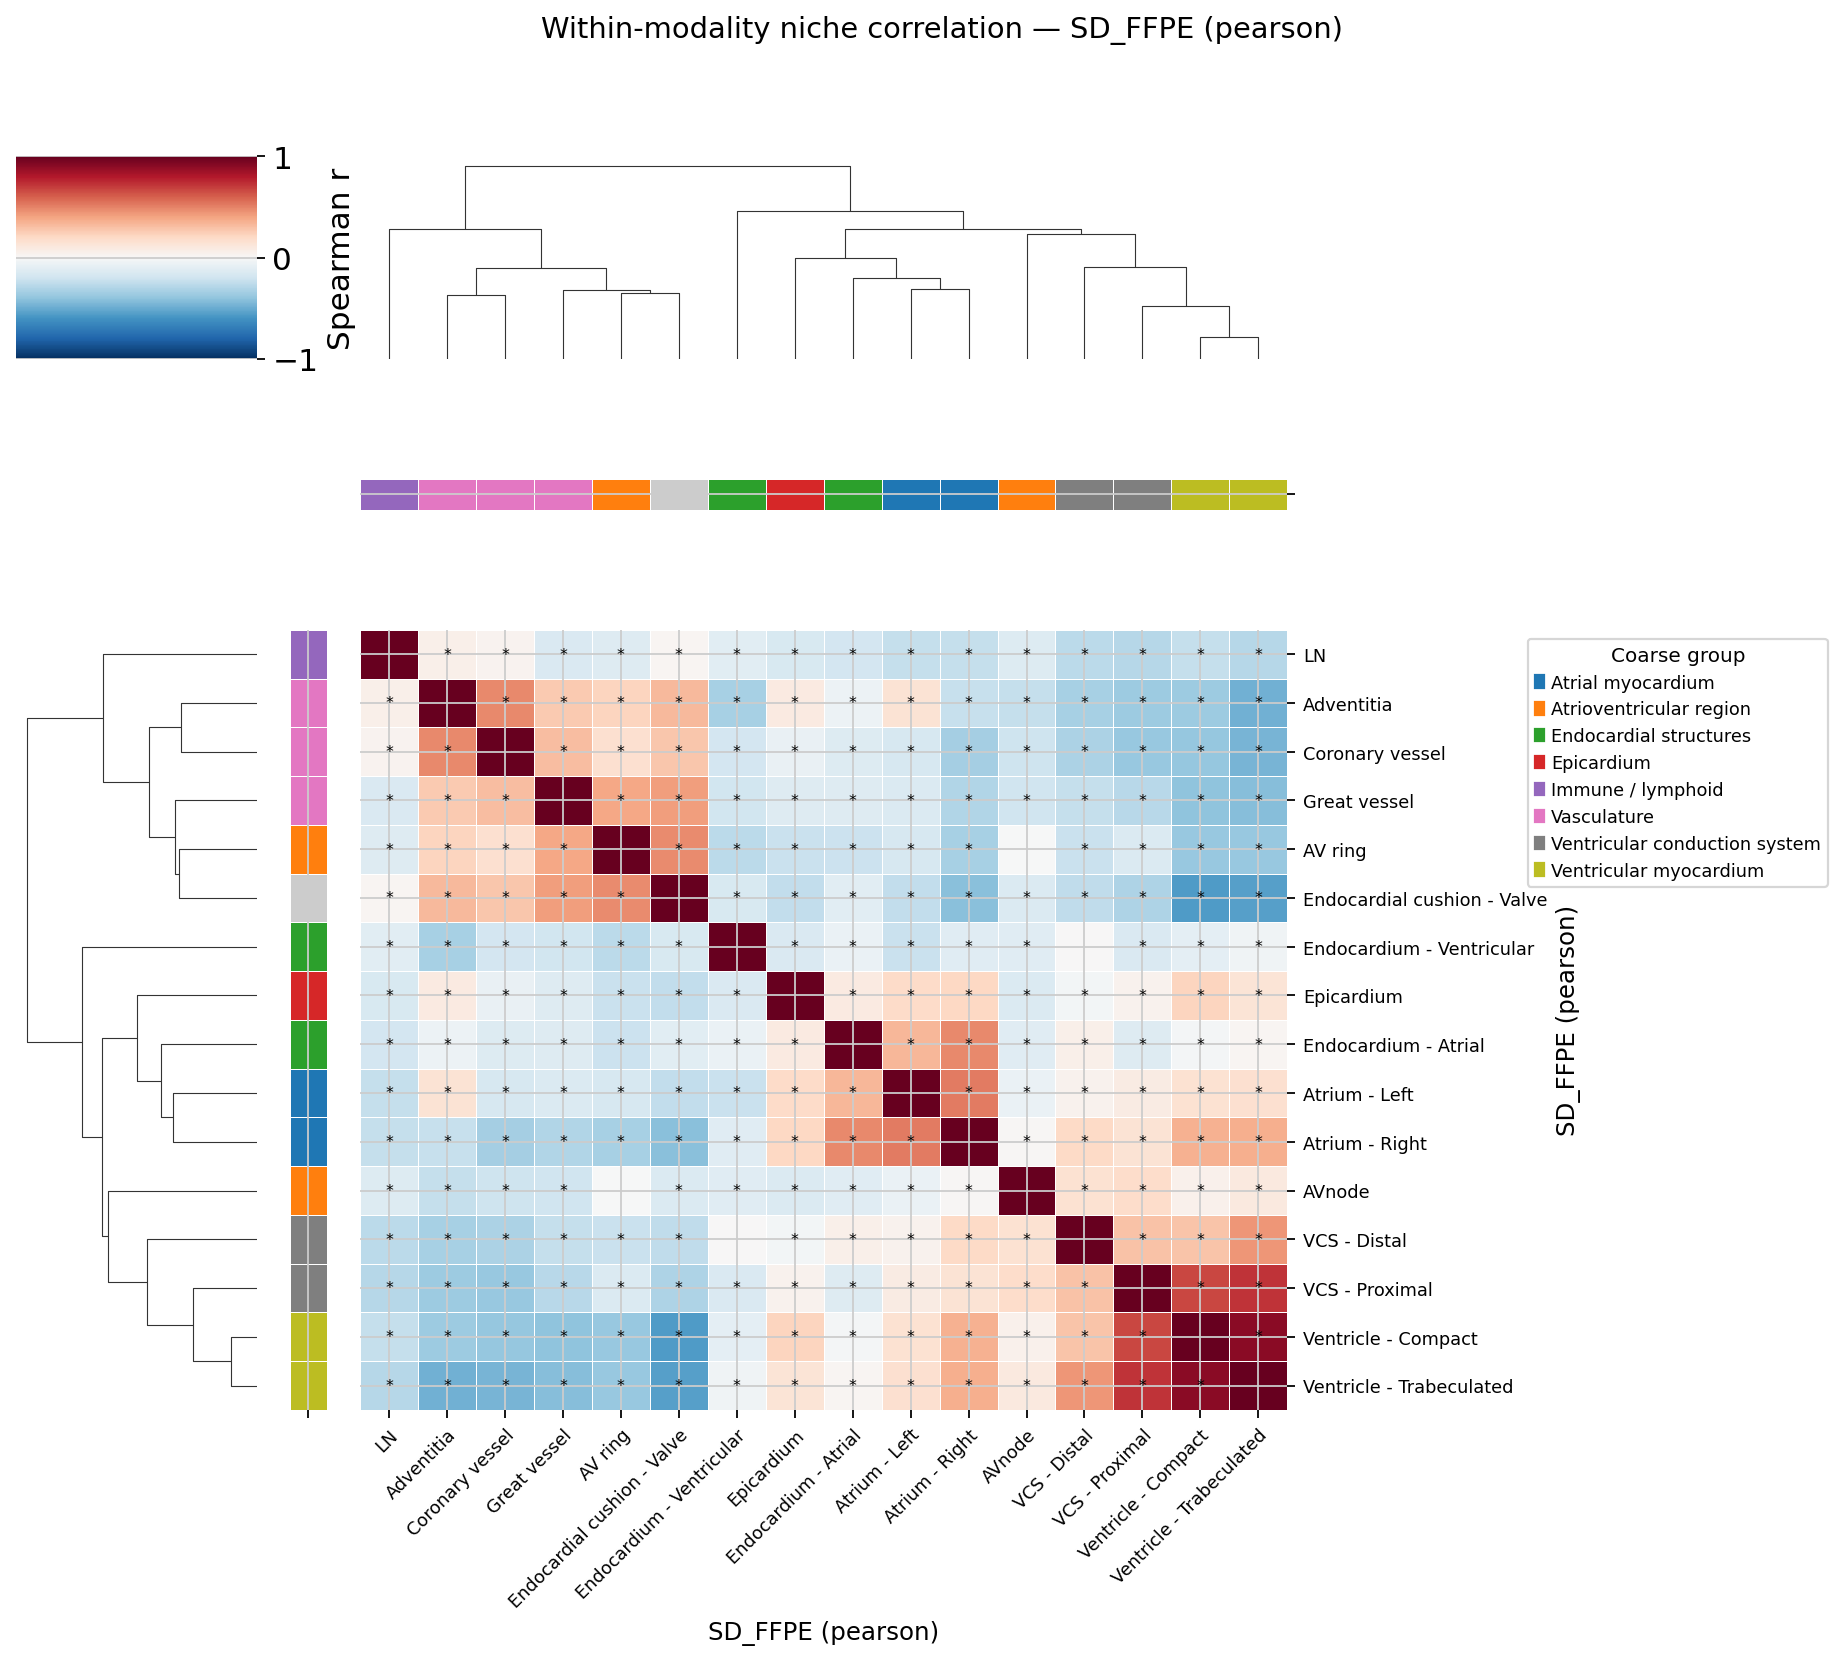

Saved: validation_plots/within_corr_SD_FFPE_spearman.png


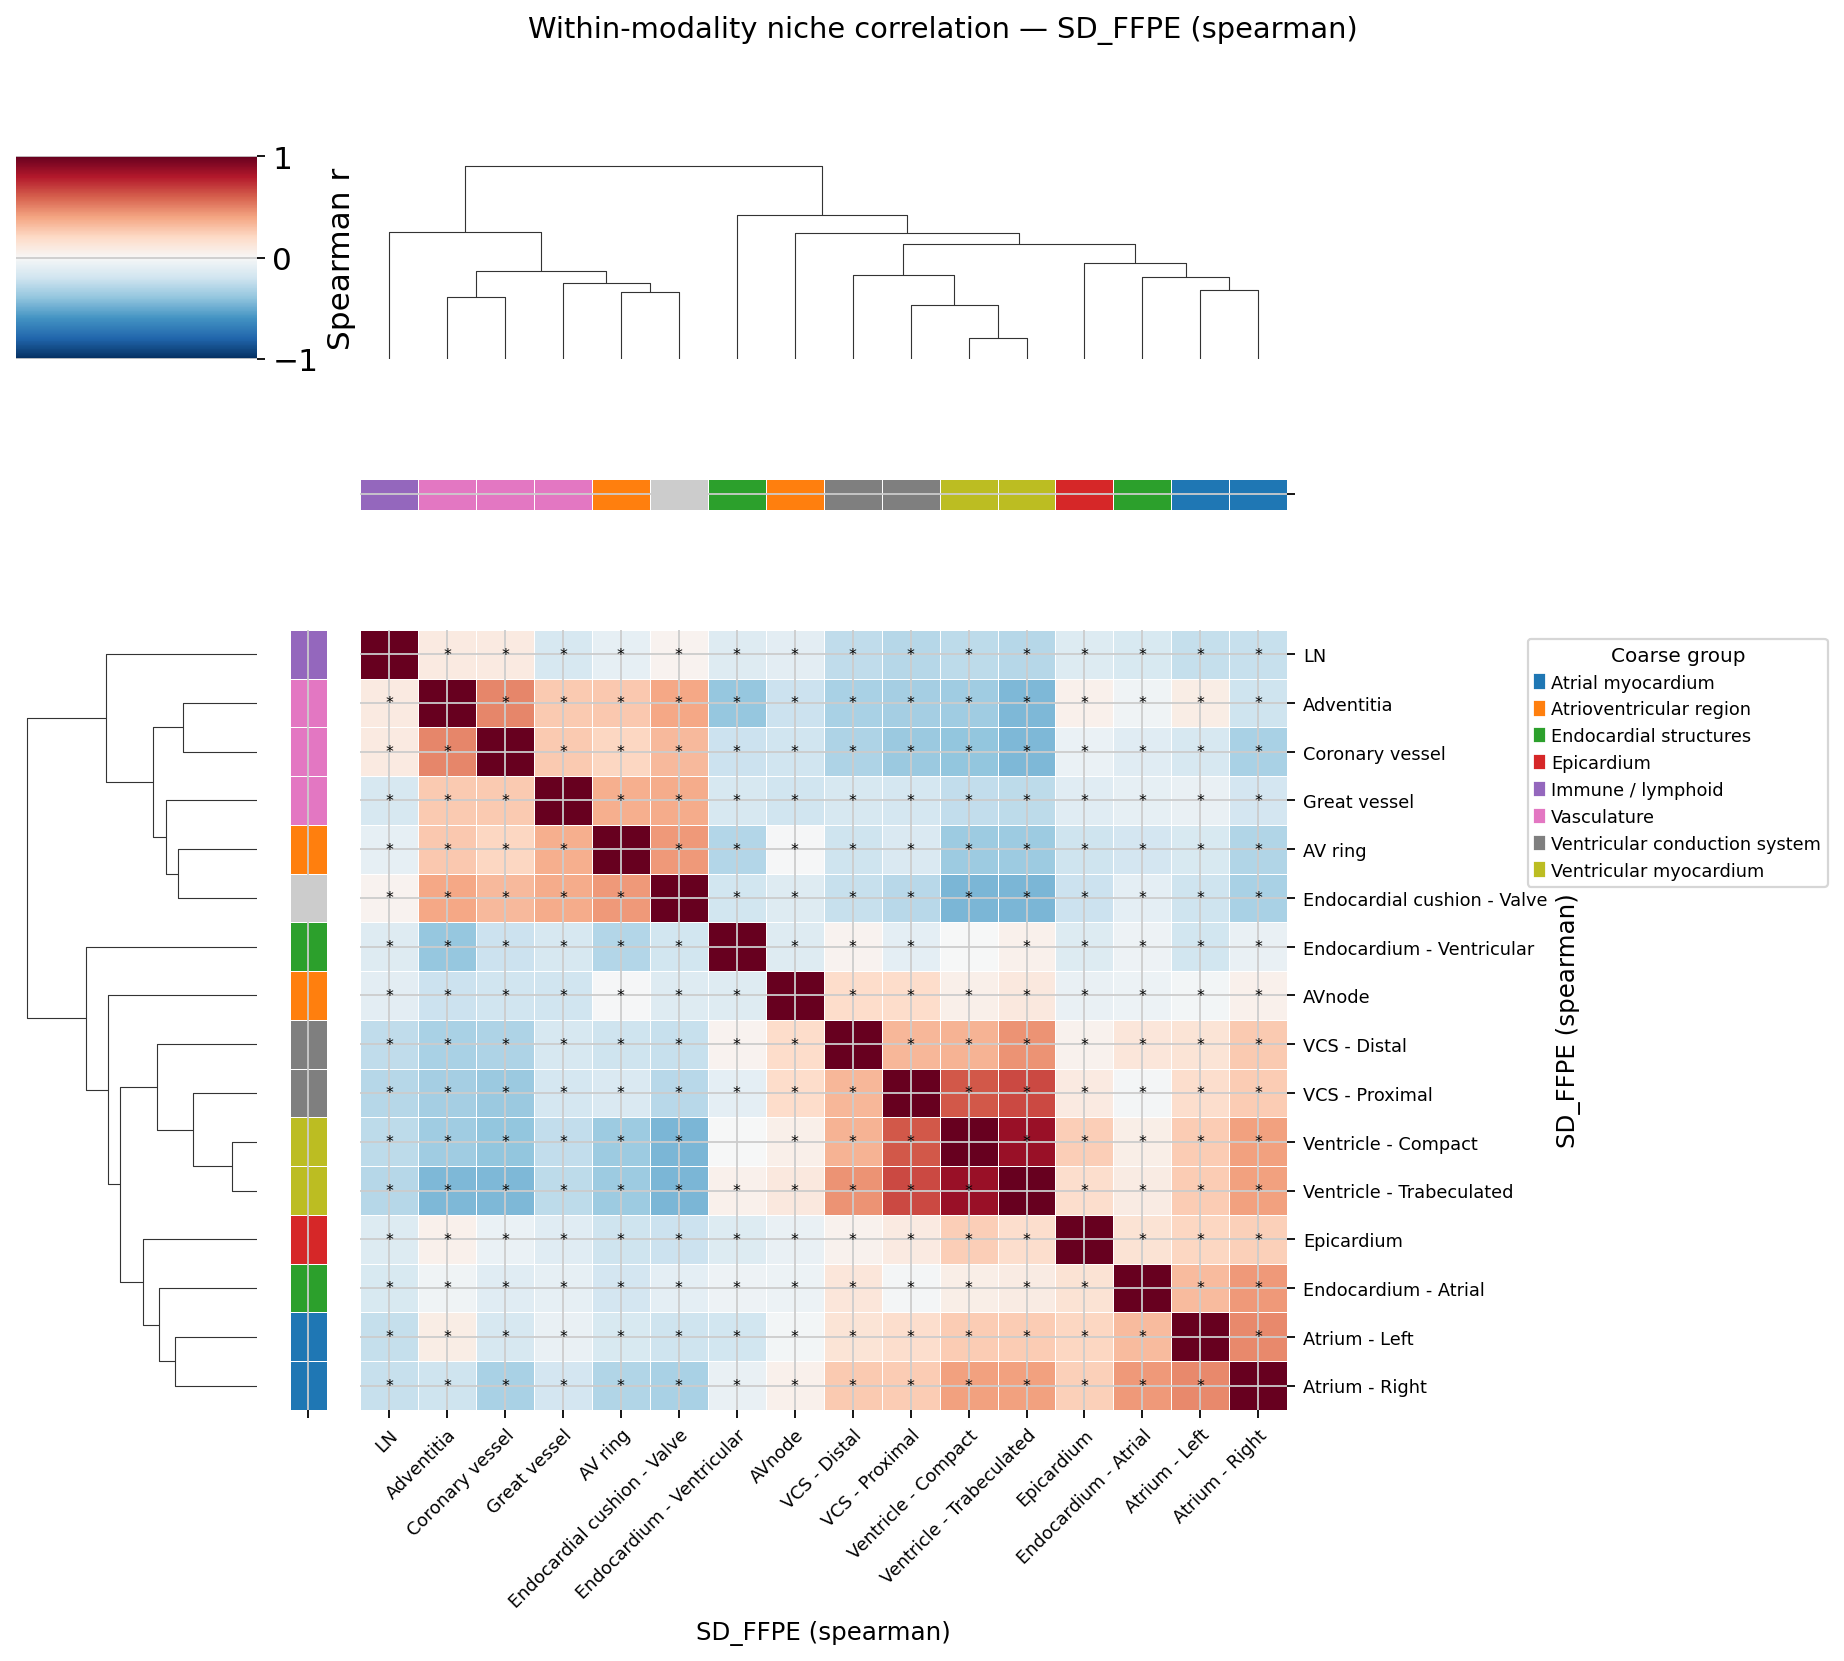

Saved: validation_plots/within_corr_HD_FFPE_pearson.png


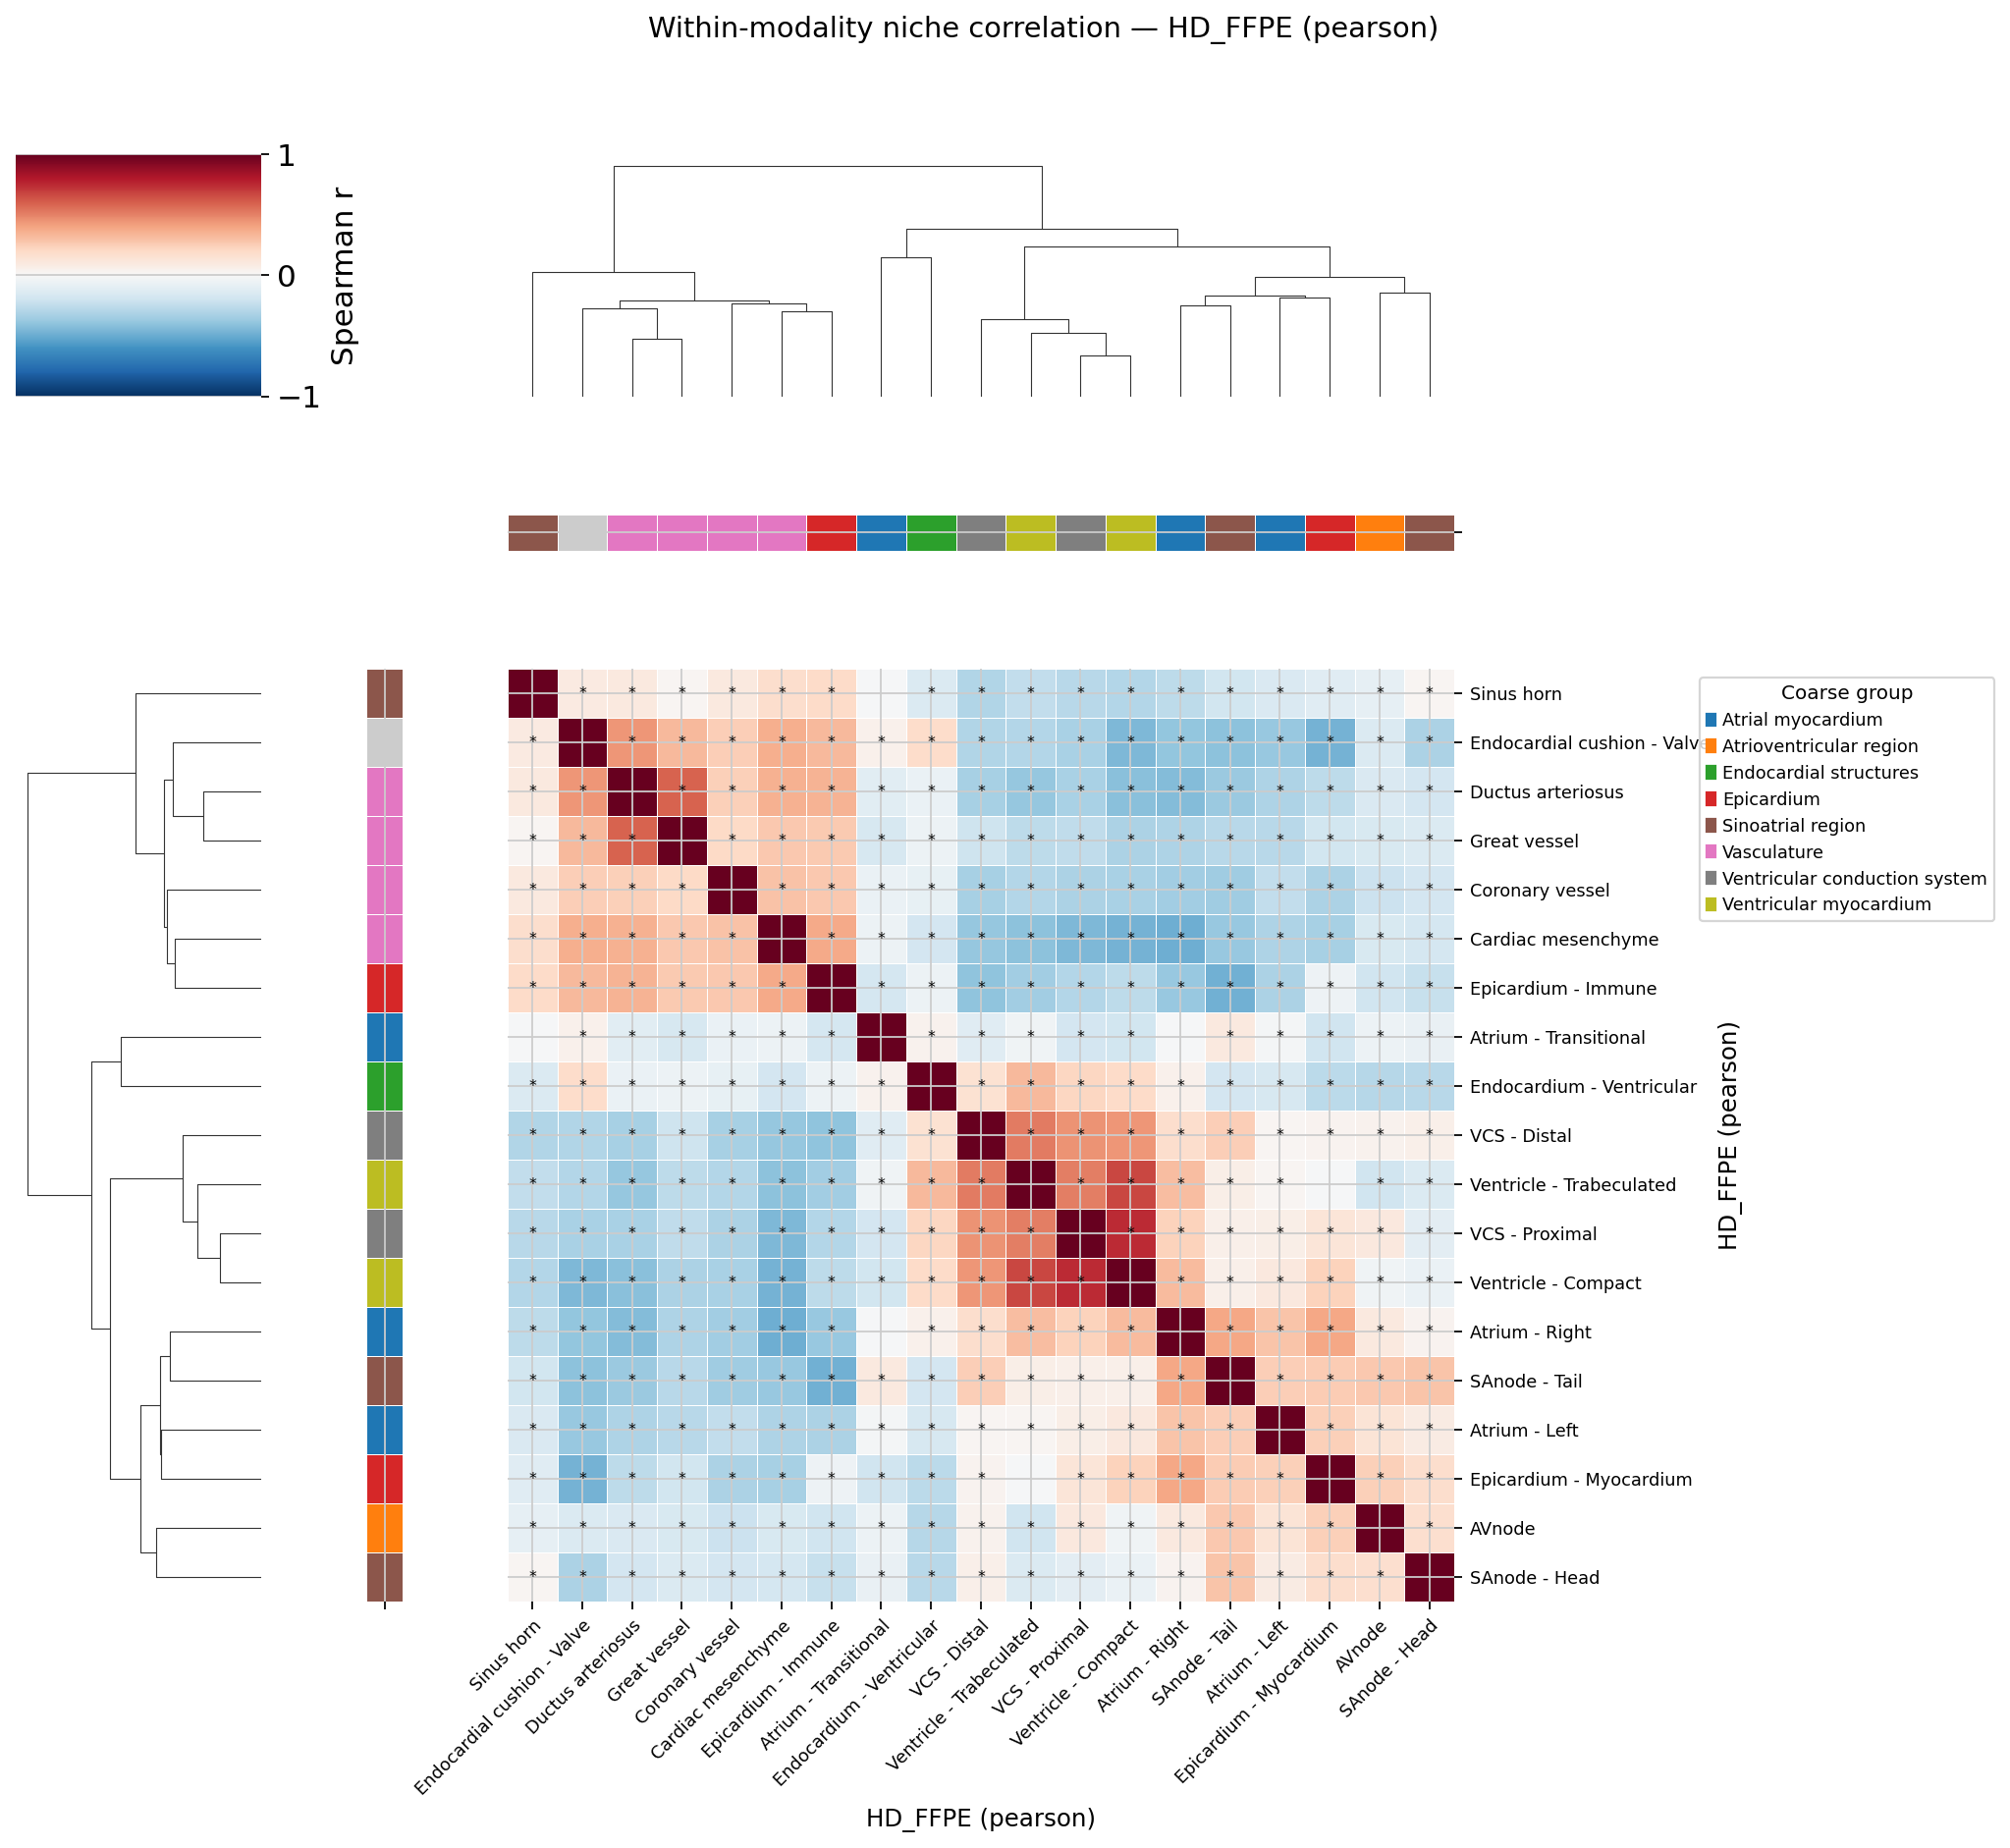

Saved: validation_plots/within_corr_HD_FFPE_spearman.png


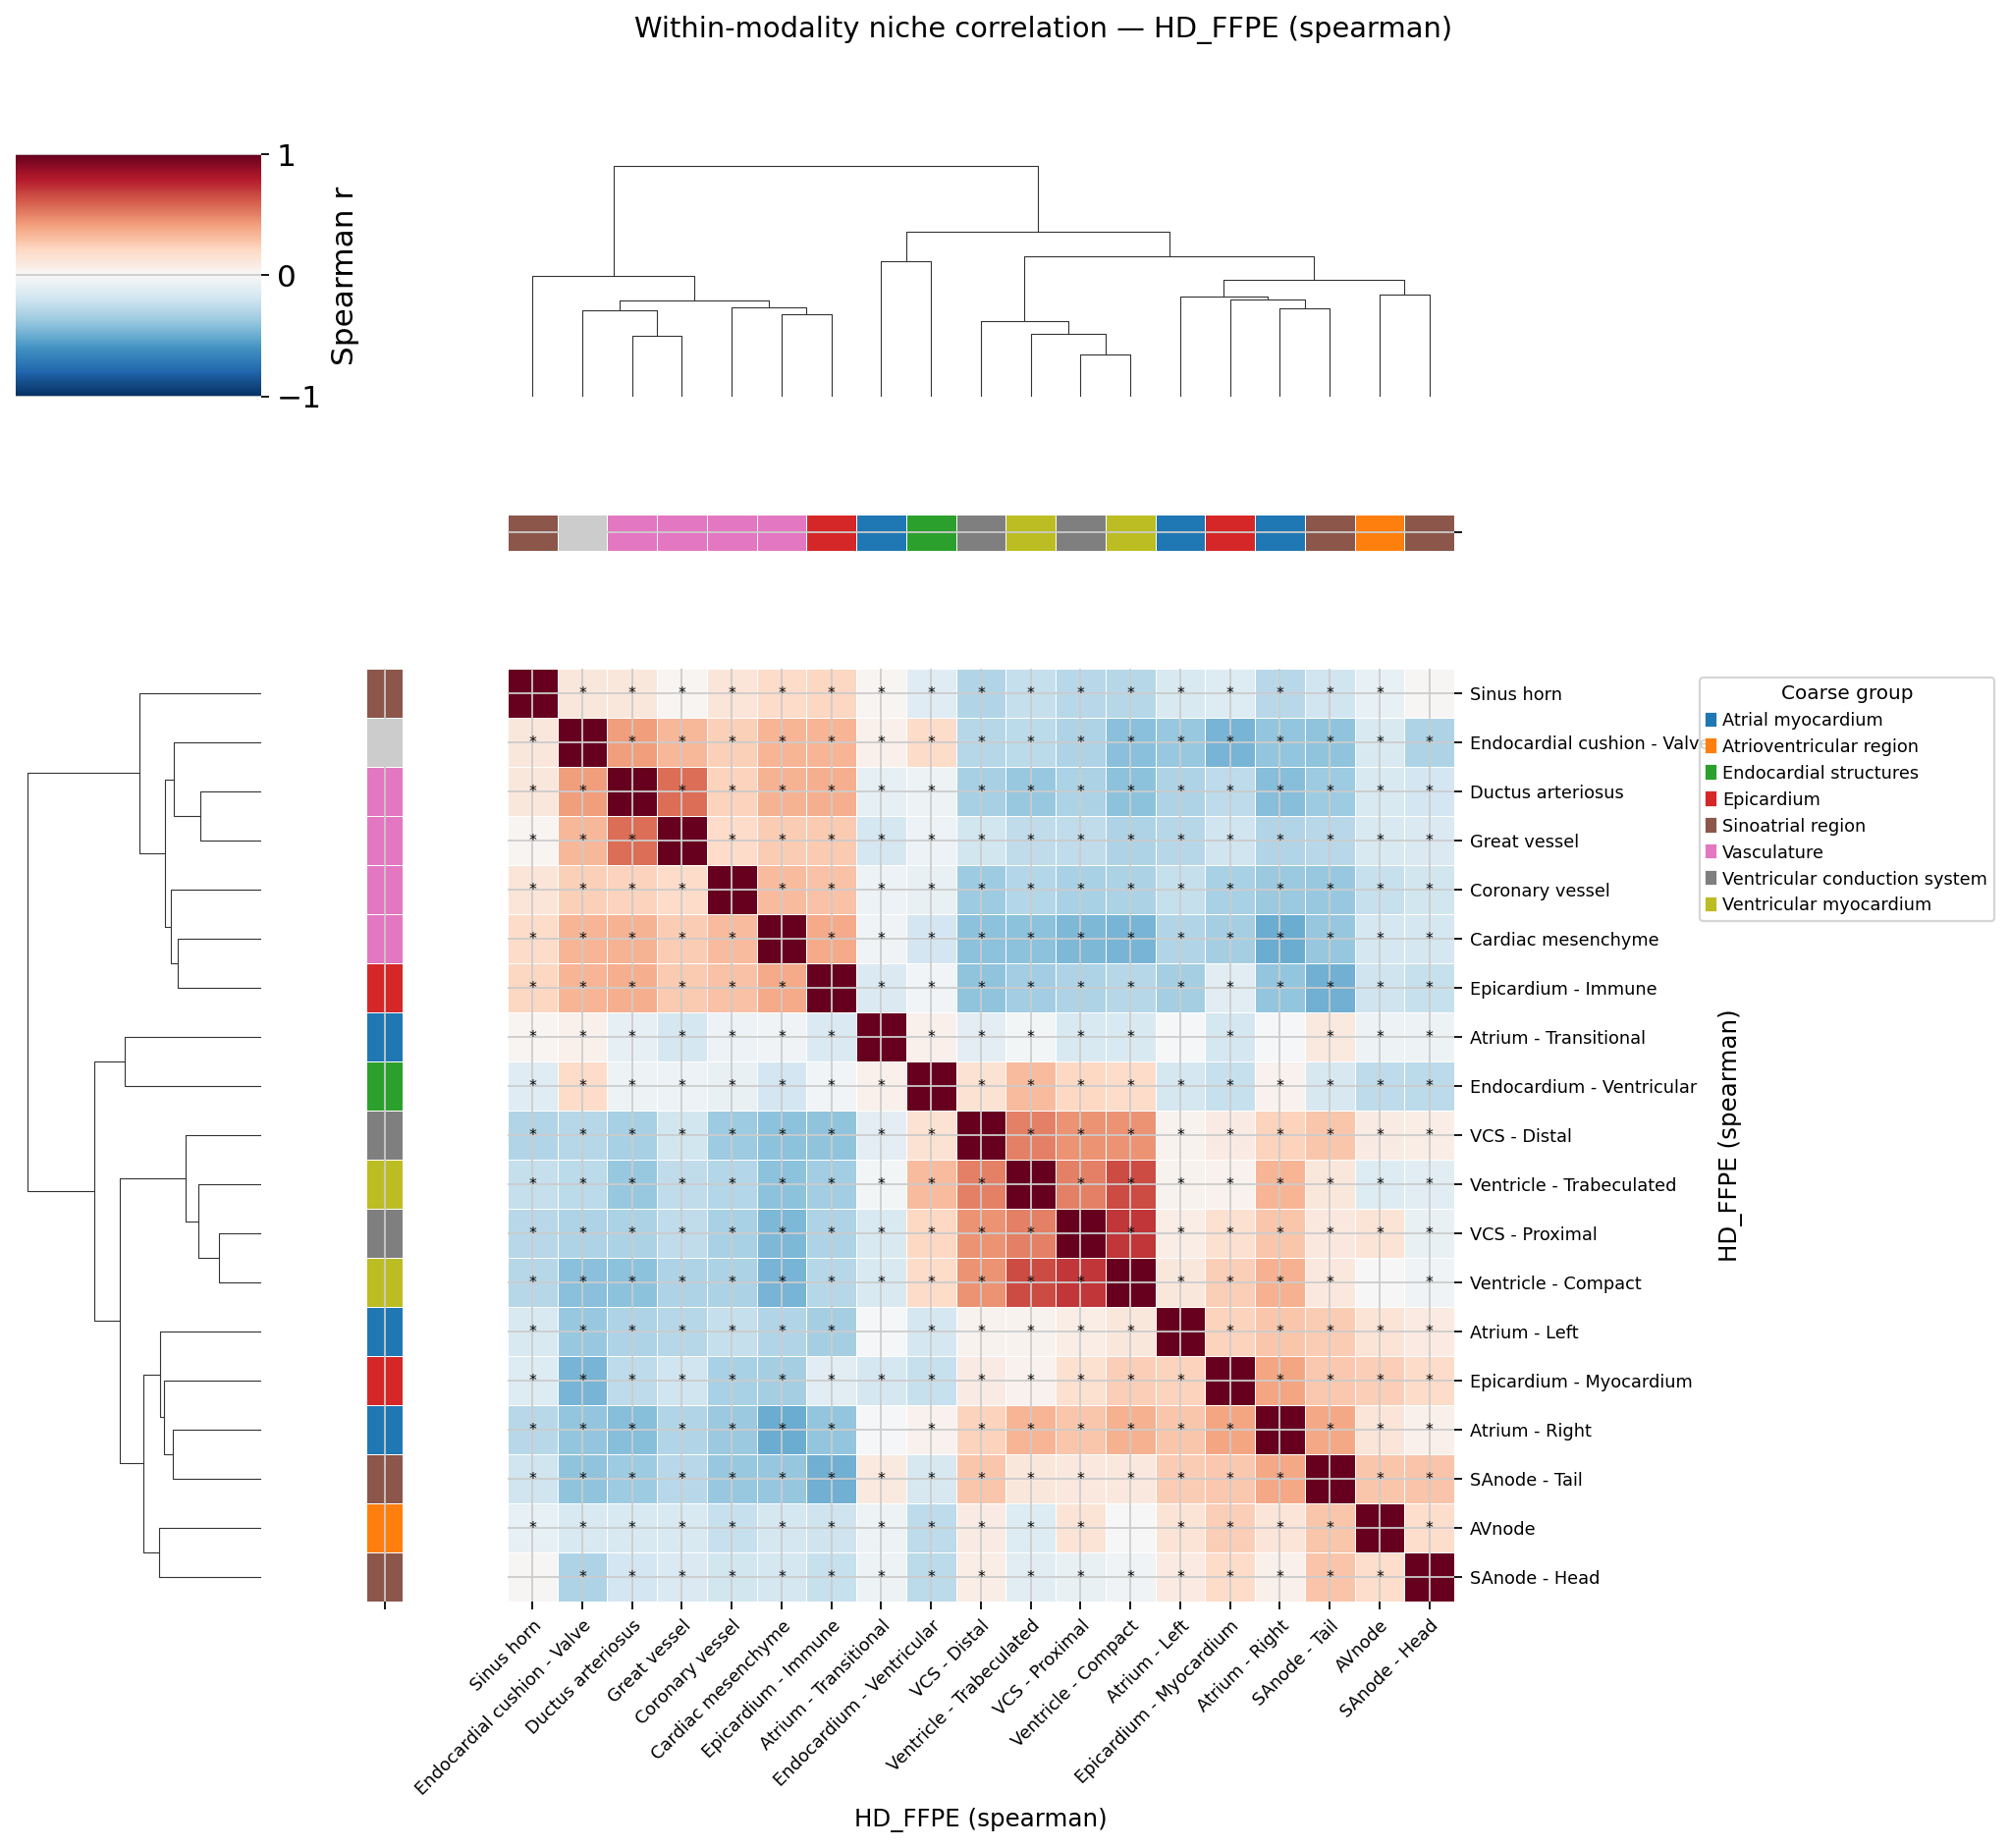

In [31]:
# Once again, calculate correlations
# run with both methods and compare
modality_pbs = [
    (pb_sd3p,  "SD_3p"),
    (pb_sdffe, "SD_FFPE"),
    (pb_hd,    "HD_FFPE"),
]

for pb, label in modality_pbs:
    for method in ["pearson", "spearman"]:
        r_matrix, p_matrix = niche_correlation_matrix(
            pb, niche_col="niche", method=method,
        )
        plot_clustermap(
            r_matrix         = r_matrix,
            p_matrix         = p_matrix,
            modality_label   = f"{label} ({method})",
            coarse_group_map = coarse_group_map,
            save_path        = f"validation_plots/"
                               f"within_corr_{label}_{method}.png",
        )

In [32]:
# Once again, presence of niches across modalities
df = pd.crosstab(adata_sd.obs[niche_col],
           adata_sd.obs['modality'])
df = (df>0)
df.reset_index(inplace=True)
df.columns = ['Niche','SD_3p','SD_FFPE']
# add hd niches
hd_df = pd.DataFrame({'Niche':adata_hd.obs[niche_col].unique(),
                      'HD_FFPE':1
                     })
df = df.merge(hd_df,on='Niche',how='outer')
df = df.fillna(0)
df[['SD_3p','SD_FFPE','HD_FFPE']] = df[['SD_3p','SD_FFPE','HD_FFPE']].astype('Int64')
df

,Niche,SD_3p,SD_FFPE,HD_FFPE
0,AV ring,1,1,0
1,AVnode,1,1,1
2,Adventitia,1,1,0
3,Atrium - Left,1,1,1
4,Atrium - Right,1,1,1
5,Atrium - Transitional,0,0,1
6,Cardiac mesenchyme,0,0,1
7,Coronary vessel,1,1,1
8,Ductus arteriosus,1,0,1
9,Endocardial cushion - Valve,1,1,1


# Construct a hirarchical niche tree

- AVnode will be under "Pacemaker conduction system"
- "Cardiac mesenchyme" will be renamed as "Connective tissue"
- "Adventitia" will be renamed as "Connective tissue"
- Merge "Epicardium - Myocardium" and "Epicardium - Immune"

In [46]:
niche_tree = {
    "Ventricle": {
        "Ventricle - Compact":       {},
        "Ventricle - Trabeculated":  {},
        "VCS - Proximal":            {},
        "VCS - Distal":              {},
        "Endocardium - Ventricular": {},
    },

    "Atrium": {
        "Atrium - Left":         {},
        "Atrium - Right":        {},
        "Atrium - Transitional": {},
        "Endocardium - Atrial":  {},
    },

    "Pacemaker conduction system": {
        "SAnode":    {},  # --> will be "Sinoatrial region - non-terminal category"
        "Sinus horn":    {},
        "SAnode - Head": {},
        "SAnode - Tail": {},
        "AVnode": {},   # --> will be "AV nodal region"
    },

    "Vasculature": {
        "Great vessel":      {},
        "Ductus arteriosus": {},
        "Coronary vessel":   {},
        "Connective tissue": {},
        "Adventitia": {},         # --> will be "Connective tissue"
        "Cardiac mesenchyme": {}, # --> will be "Connective tissue"
    },

    "AV junction": {
        "AV ring":                    {},
        "Endocardial cushion - Valve": {},
    },
    
    "Epicardium": {},               # --> will be "Epicardial region"
    "Epicardium - Immune": {},      # --> will be "Epicardial region"
    "Epicardium - Myocardium": {},  # --> will be "Epicardial region"
    
    "LN": {},
}

rename_mapping = {
    "LN": "Lymph node",
    "SAnode": 'Sinoatrial region - non-terminal category',
    "SAnode - Head": "SA node - Head",
    "SAnode - Tail": "SA node - Tail",
    "AVnode": "AV nodal region",
    "Epicardium - Immune": "Epicardial region",
    "Epicardium - Myocardium": "Epicardial region",
    "Epicardium": "Epicardial region",
    "Cardiac mesenchyme": "Connective tissue",
    "Adventitia": "Connective tissue"
}

In [47]:
def get_all_leaves(tree):
    """Return all leaf node names."""
    leaves = []
    for key, subtree in tree.items():
        if not subtree:
            leaves.append(key)
        else:
            leaves.extend(get_all_leaves(subtree))
    return leaves

all_leaves     = get_all_leaves(niche_tree)

print("Coarse groups:", list(niche_tree.keys()))
print("All leaves:", all_leaves)

Coarse groups: ['Ventricle', 'Atrium', 'Pacemaker conduction system', 'Vasculature', 'AV junction', 'Epicardium', 'Epicardium - Immune', 'Epicardium - Myocardium', 'LN']
All leaves: ['Ventricle - Compact', 'Ventricle - Trabeculated', 'VCS - Proximal', 'VCS - Distal', 'Endocardium - Ventricular', 'Atrium - Left', 'Atrium - Right', 'Atrium - Transitional', 'Endocardium - Atrial', 'SAnode', 'Sinus horn', 'SAnode - Head', 'SAnode - Tail', 'AVnode', 'Great vessel', 'Ductus arteriosus', 'Coronary vessel', 'Connective tissue', 'Adventitia', 'Cardiac mesenchyme', 'AV ring', 'Endocardial cushion - Valve', 'Epicardium', 'Epicardium - Immune', 'Epicardium - Myocardium', 'LN']


In [48]:
# create labels in each dataset

### Visium SD ###
print('Visium SD')
fine_labels = []
coarse_labels = []
for label in adata_sd.obs[niche_col]:
    if label in all_leaves:
        fine_labels.append(label)
    else:
        fine_labels.append('NA')
    
    if label in list(niche_tree.keys()):
        coarse_labels.append(label)
    else:
        for coarse,subtree in niche_tree.items():
            if label in subtree:
                coarse_labels.append(coarse)
    
    # confirm coarse_labels is same number as fine_labels
    if len(fine_labels)!=len(coarse_labels):
        raise ValueError(f"coarse_label didn't assign. label: {label}")
print(len(fine_labels))
print(len(coarse_labels))
adata_sd.obs['niche_fine_Apr2026'] = fine_labels
adata_sd.obs['niche_coarse_Apr2026'] = coarse_labels

### Visium HD ###
print('Visium HD')
fine_labels = []
coarse_labels = []
for label in adata_hd.obs[niche_col]:
    if label in all_leaves:
        fine_labels.append(label)
    else:
        fine_labels.append('NA')
    
    if label in list(niche_tree.keys()):
        coarse_labels.append(label)
    else:
        for coarse,subtree in niche_tree.items():
            if label in subtree:
                coarse_labels.append(coarse)
    
    # confirm coarse_labels is same number as fine_labels
    if len(fine_labels)!=len(coarse_labels):
        raise ValueError(f"coarse_label didn't assign. label: {label}")
print(len(fine_labels))
print(len(coarse_labels))
adata_hd.obs['niche_fine_Apr2026'] = fine_labels
adata_hd.obs['niche_coarse_Apr2026'] = coarse_labels

# rename
adata_sd.obs.replace({
    'niche_fine_Apr2026':rename_mapping,
    'niche_coarse_Apr2026':rename_mapping,
},inplace=True)
adata_hd.obs.replace({
    'niche_fine_Apr2026':rename_mapping,
    'niche_coarse_Apr2026':rename_mapping,
},inplace=True)

Visium SD
39223
39223
Visium HD
215913
215913


In [49]:
df = adata_sd.obs[['niche_coarse_Apr2026','niche_fine_Apr2026']].copy()
df = df.reset_index(drop=True)
display(df.drop_duplicates())

df = adata_hd.obs[['niche_coarse_Apr2026','niche_fine_Apr2026']].copy()
df = df.reset_index(drop=True)
display(df.drop_duplicates())

,niche_coarse_Apr2026,niche_fine_Apr2026
0,Ventricle,Endocardium - Ventricular
1,Ventricle,Ventricle - Compact
3,Vasculature,Great vessel
7,Atrium,Atrium - Left
8,Epicardial region,Epicardial region
9,Ventricle,Ventricle - Trabeculated
12,Vasculature,Connective tissue
16,Atrium,Endocardium - Atrial
158,Atrium,Atrium - Right
287,Ventricle,VCS - Distal


,niche_coarse_Apr2026,niche_fine_Apr2026
0,Vasculature,Coronary vessel
3,Epicardial region,Epicardial region
10,Vasculature,Connective tissue
1774,Vasculature,Ductus arteriosus
6519,Vasculature,Great vessel
19207,Atrium,Atrium - Left
21009,Atrium,Atrium - Right
22312,AV junction,Endocardial cushion - Valve
24839,Pacemaker conduction system,SA node - Head
25258,Pacemaker conduction system,SA node - Tail


In [50]:
adata_sd.obs.drop(columns=niche_col,inplace=True)
adata_hd.obs.drop(columns=niche_col,inplace=True)

# Save

In [51]:
print(adata_sd.X.data[:10])
print(adata_hd.X.data[:10])

[  1.  42.   1. 127.  35. 138.  51.   1. 118. 174.]
[1. 1. 1. 1. 1. 1. 1. 2. 1. 1.]


In [52]:
adata_sd.write(adatasd_path)
adata_hd.write('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_niche-sel_raw.h5ad')

In [53]:
adata_hd

AnnData object with n_obs × n_vars = 215913 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-sc

In [54]:
# how many coarse-grained annotations do we have
sd_labels = set(adata_sd.obs['niche_coarse_Apr2026'])
hd_labels = set(adata_hd.obs['niche_coarse_Apr2026'])
print(len(sd_labels.union(hd_labels)))
print(sd_labels.union(hd_labels))

7
{'Atrium', 'AV junction', 'Ventricle', 'Pacemaker conduction system', 'Vasculature', 'Lymph node', 'Epicardial region'}


In [55]:
# how many terminal annotations do we have
sd_labels = set(adata_sd.obs['niche_fine_Apr2026'])
hd_labels = set(adata_hd.obs['niche_fine_Apr2026'])
union = sd_labels.union(hd_labels)
union = {x for x in union if 'non-terminal category' not in x}
print(len(union))
print(union)

21
{'AV nodal region', 'Atrium - Right', 'VCS - Proximal', 'Endocardium - Ventricular', 'Ductus arteriosus', 'SA node - Tail', 'Epicardial region', 'Endocardial cushion - Valve', 'AV ring', 'Coronary vessel', 'SA node - Head', 'Lymph node', 'Connective tissue', 'Great vessel', 'Endocardium - Atrial', 'Ventricle - Trabeculated', 'Sinus horn', 'VCS - Distal', 'Atrium - Transitional', 'Atrium - Left', 'Ventricle - Compact'}


In [ ]:
niche_tree = {
    "Ventricle": {
        "Ventricle - Compact":       {},
        "Ventricle - Trabeculated":  {},
        "VCS - Proximal":            {},
        "VCS - Distal":              {},
        "Endocardium - Ventricular": {},
    },

    "Atrium": {
        "Atrium - Left":         {},
        "Atrium - Right":        {},
        "Atrium - Transitional": {},
        "Endocardium - Atrial":  {},
    },

    "Pacemaker conduction system": {
        "Sinus horn":    {},
        "SA node - Head": {},
        "SA node - Tail": {},
        "AV nodal region": {},
    },

    "Vasculature": {
        "Great vessel":      {},
        "Ductus arteriosus": {},
        "Coronary vessel":   {},
        "Connective tissue":{},
    },

    "AV junction": {
        "AV ring":                    {},
        "Endocardial cushion - Valve": {},
    },
    
    "Epicardial region": {},
    
    "Lymph node": {},
}